In [2]:
import os
import pandas as pd

def collect_csv_files(folder_path):
    csv_files = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    return csv_files

def read_and_merge_csvs(csv_files):
    data_frames = []
    
    for file in csv_files:
        df = pd.read_csv(file)
        
        # Extract filename parts
        filename = os.path.basename(file)
        file_parts = filename.split('_')
        
        # Add filename parts as new columns
        for i, part in enumerate(file_parts):
            df[f'filename_part_{i}'] = part
        
        data_frames.append(df)
    
    # Concatenate all dataframes
    merged_df = pd.concat(data_frames, axis=0, ignore_index=True, join='outer')
    return merged_df

def main():
    name = 'Fiona'
    folder_path = f'/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/{name}/Conflict Days'
    csv_files = collect_csv_files(folder_path)
    merged_df = read_and_merge_csvs(csv_files)
    
    # Save merged dataframe to a new CSV file
    output_file = os.path.join(folder_path, f'{name}_merged_data.csv')
    merged_df.to_csv(output_file, index=False)

    print(f"Merged CSV saved to: {output_file}")

if __name__ == "__main__":
    main()


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_94855/172130867.py:16: DtypeWarning: Columns (39,46,47,50,51,52,53,54,63,64,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Merged CSV saved to: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/Fiona/Conflict Days/Fiona_merged_data.csv


In [50]:
import re

name = 'Sonic'
#load the merged data
folder_path = f'/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/{name}/Conflict Days'

output_file = os.path.join(folder_path, f'{name}_merged_data.csv')

df = pd.read_csv(output_file)

# REMOVE ALL SkippedFrameTimeInfo columns
df = df.loc[:, ~df.columns.str.contains('SkippedFrameTimeInfo')]

# Add a new column 'Date' that combines the Month, Day, and Year columns
df['Date'] = pd.to_datetime(df[['Month', 'Day', 'Year']]).dt.strftime('%m/%d/%Y')

#iterate through the rows and make a new column called 'Outcome' where 1 if Reward = 'Rewarded' and 0 if Reward = 'Unrewarded'
df['Outcome'] = df['Reward'].apply(lambda x: 1 if x == 'Rewarded' else 0)


/Users/kevinmastro/opt/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3326: DtypeWarning: Columns (53) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [68]:
import pandas as pd 
import os
import re

# For individual files
# name = 'Fiona'
# folder_path = f'/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/{name}/Conflict Days'  
# file_name = f'{name}_merged_data.csv'

# Loading for the merged file 
folder_path = f'/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/'  
file_name = f'master_merged_data.csv'

# load csv from path 
df_master = pd.read_csv(os.path.join(folder_path, file_name))
df_master

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_3091/3172409833.py:15: DtypeWarning: Columns (39,43,45,46,47,50,51,52,53,54,63,64,69,70,75) have mixed types. Specify dtype option on import or set low_memory=False.
  df_master = pd.read_csv(os.path.join(folder_path, file_name))


,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,SkippedFrameTimeInfo_2051,SkippedFrameTimeInfo_2052,SkippedFrameTimeInfo_2053,SkippedFrameTimeInfo_2054,SkippedFrameTimeInfo_2055,SkippedFrameTimeInfo_2056,SkippedFrameTimeInfo_2057,SkippedFrameTimeInfo_2058,SkippedFrameTimeInfo_2059,SkippedFrameTimeInfo_2060
0,1,1,1,1,1,0,NaN,0.000000e+00,2024,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,2,1,1,0,NaN,1.843110e+05,2024,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,3,1,1,0,NaN,1.963903e+05,2024,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,4,1,1,6,NaN,2.066054e+05,2024,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,5,1,1,0,NaN,2.106743e+05,2024,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1028030,337,17,17,1,1,0,NaN,3.686018e+06,2023,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1028031,338,17,18,1,1,0,NaN,3.692084e+06,2023,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1028032,339,17,19,1,1,0,NaN,3.696984e+06,2023,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1028033,340,17,20,1,1,0,NaN,3.702433e+06,2023,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
import pandas as pd

# Assuming df_master is your DataFrame
df_master['Date'] = pd.to_datetime(df_master[['Year', 'Month', 'Day']])
df_master['Session_ID'] = df_master['Date'].astype(str) + '_' + df_master['Animal_Name']
df_master['Session_ID_Trial'] = df_master['Session_ID'] + '_' + df_master['Trial'].astype(str)

# Checking the lengths before and after dropping duplicates
print("Length before dropping duplicates:", len(df_master))

# Drop duplicate rows based on Session_ID_Trial
tmp = df_master.drop_duplicates(subset=['Session_ID_Trial'])

print("Length after dropping duplicates:", len(tmp))

tmp = tmp.loc[:, ~tmp.columns.str.contains('SkippedFrameTimeInfo')]


Length before dropping duplicates: 1028035
Length after dropping duplicates: 308610


In [72]:
# overwrite master_merged_data.csv
tmp.to_csv(os.path.join(folder_path, file_name), index=False)

In [79]:

# print(tmp.columns)

# For each unique Session_ID, find the min and max values in 'ProbReward' and put into a column called 'prob_Condition' in the format of [max-min]

for session_id in tmp['Session_ID'].unique():
    # Get the rows for the current session_id
    session_rows = tmp[tmp['Session_ID'] == session_id]
    
    # Find the min and max values of 'ProbReward'
    min_prob = session_rows['ProbReward'].min()
    max_prob = session_rows['ProbReward'].max()

    # if max_prob < 1.0 multiple by 100
    # if max_prob > 1.0 drop .0
    if max_prob <= 1.0:
        min_prob *= 100
        max_prob *= 100
    else:
        continue

    # Convert min_prob and max_prob to integers to remove the decimal point
    min_prob = int(min_prob)
    max_prob = int(max_prob)
    

    # Create the prob_Condition string
    prob_condition = f"{max_prob}-{min_prob}"
    # print(prob_condition)
    
    # Update the prob_Condition column for these rows
    tmp.loc[tmp['Session_ID'] == session_id, 'prob_Condition'] = prob_condition




In [193]:
file_name

'Sunflower_summary_statistics.png'

In [194]:
file_name = f'preprocessed_master_merged_data.csv'
tmp.to_csv(os.path.join(folder_path, file_name), index=False)
# tmp

In [195]:
os.path.join(folder_path, file_name)

'/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/preprocessed_master_merged_data.csv'

In [94]:


# FOr each unique Session_ID, create a Switch column by comparing the current StimuliChosen with the previous trial's. If the StimuliChosen is different, set Switch to 1, otherwise set it to 0.
for session_id in tmp['Session_ID'].unique():
    # Get the rows for the current session_id
    session_rows = tmp[tmp['Session_ID'] == session_id]
    
    # Iterate through the rows and compare with the previous row
    for i in range(1, len(session_rows)):
        if session_rows.iloc[i]['StimuliChosen'] != session_rows.iloc[i - 1]['StimuliChosen']:
            tmp.loc[session_rows.index[i], 'Switch'] = 1
        else:
            tmp.loc[session_rows.index[i], 'Switch'] = 0


# FOr each unique Session_ID, create a highport_selected column 


In [106]:
# FOr each unique Session_ID, create a 'Decision' column by giive a 1 if the current StimuliChosen = 'TargetA' and 0 if 'TargetB'
for session_id in tmp['Session_ID'].unique():
    # Get the rows for the current session_id
    session_rows = tmp[tmp['Session_ID'] == session_id]
    
    # Iterate through the rows and compare with the previous row
    for i in range(0, len(session_rows)):
        if session_rows.iloc[i]['StimuliChosen'] == 'TargetA':
            tmp.loc[session_rows.index[i], 'Decision'] = 1
        else:
            tmp.loc[session_rows.index[i], 'Decision'] = 0

In [107]:
#  Target is always TargetA or 1, based on how i coded the above....
tmp['Target'] = 1


In [111]:
tmp['Session_ID'].unique

<bound method Series.unique of 0             2024-03-06_Fiona
1             2024-03-06_Fiona
2             2024-03-06_Fiona
3             2024-03-06_Fiona
4             2024-03-06_Fiona
                  ...         
310995    2023-11-13_Sunflower
310996    2023-11-13_Sunflower
310997    2023-11-13_Sunflower
310998    2023-11-13_Sunflower
312209                     NaN
Name: Session_ID, Length: 308610, dtype: object>

In [118]:
# plot AbsoluteTrialStartTime
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# session_tmp = tmp[tmp['Session_ID'] == '2024-03-06_Fiona']

# AbsoluteTrialStartTime counts upwards in milliseconds, so we need to convert it to seconds
# tmp['TrialStartTime_seconds'] = tmp['AbsoluteTrialStartTime'] / 1000
# tmp['TrialStartTime_mins'] = tmp['TrialStartTime_seconds'] / 60

# plt.plot(tmp['TrialStartTime_mins'])

# Loop through each unique Session ID and calculate the ITI based on the 'TrialStartTime_seconds'
for session_id in tmp['Session_ID'].unique():
    # Get the rows for the current session_id
    session_rows = tmp[tmp['Session_ID'] == session_id]
    
    # Iterate through the rows and calculate the ITI
    for i in range(1, len(session_rows)):
        tmp.loc[session_rows.index[i], 'ITI'] = session_rows.iloc[i]['TrialStartTime_seconds'] - session_rows.iloc[i - 1]['TrialStartTime_seconds']
        # If it's the first trial, set ITI to 0
        if i == 0:
            tmp.loc[session_rows.index[i], 'ITI'] = 0


In [120]:
# min value of ITI
tmp['ITI'].min()

-4317.5033933

In [124]:
# Rows with ITI less than 0
tmp[tmp['ITI'] < 0]

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,Date,Session_ID,Session_ID_Trial,prob_Condition,Switch,Decision,Target,TrialStartTime_seconds,TrialStartTime_mins,ITI
92300,21,2,1,8,8,0,NaN,9.368092e+04,2022,4,...,2022-04-22,2022-04-22_Zazu,2022-04-22_Zazu_21,90-10,0.0,1.0,1,93.680917,1.561349,-52.657903
94067,172,4,13,3,3,6,NaN,8.469000e+05,2021,9,...,2021-09-09,2021-09-09_Zazu,2021-09-09_Zazu_172,100-0,0.0,0.0,1,846.899982,14.115000,-2231.812817
96941,144,8,4,4,4,6,NaN,1.265550e+06,2024,2,...,2024-02-20,2024-02-20_Zazu,2024-02-20_Zazu_144,80-20,0.0,0.0,1,1265.550254,21.092504,-372.926142
114542,21,2,1,3,3,6,NaN,1.101779e+05,2022,2,...,2022-02-04,2022-02-04_Zazu,2022-02-04_Zazu_21,100-0,0.0,0.0,1,110.177856,1.836298,-57.657188
121814,146,8,6,8,8,0,NaN,8.724716e+05,2021,11,...,2021-11-01,2021-11-01_Zazu,2021-11-01_Zazu_146,90-10,1.0,1.0,1,872.471637,14.541194,-1536.529184
155163,104,6,4,6,6,0,NaN,4.797198e+05,2021,11,...,2021-11-04,2021-11-04_Raven,2021-11-04_Raven_104,90-10,0.0,1.0,1,479.719828,7.995330,-12.386145
155762,51,1,51,8,91,5,NaN,3.604330e+05,2021,8,...,2021-08-17,2021-08-17_Raven,2021-08-17_Raven_51,100-0,0.0,1.0,1,360.433010,6.007217,-52.340860
160116,31,1,31,6,6,0,NaN,2.607335e+05,2021,9,...,2021-09-09,2021-09-09_Raven,2021-09-09_Raven_31,100-0,1.0,1.0,1,260.733465,4.345558,-121.725833
184752,31,1,31,1,2,0,NaN,2.524509e+05,2021,4,...,2021-04-16,2021-04-16_Raven,2021-04-16_Raven_31,NaN,1.0,0.0,1,252.450861,4.207514,-135.519590
189493,135,7,15,7,7,0,NaN,5.868553e+05,2022,1,...,2022-01-06,2022-01-06_Raven,2022-01-06_Raven_135,80-20,1.0,1.0,1,586.855341,9.780922,-1435.475176


In [128]:
tmp['prob_Condition'].unique()

array(['90-10', '80-20', '100-0', '80-80', '100-100', nan], dtype=object)

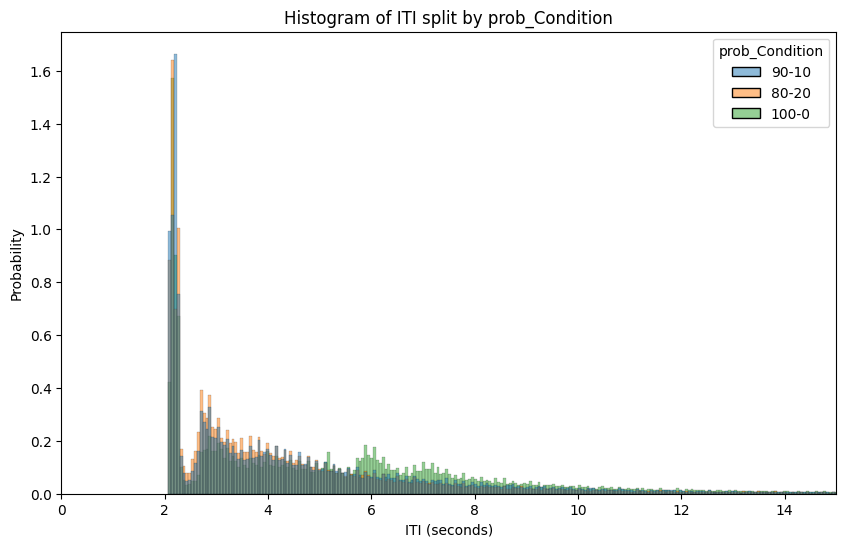

In [ ]:
# Plot a histogram of ITI split by 'prob_Condition', normalized for each prob_Condition
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_df, x='ITI', hue='prob_Condition', common_norm=False, bins=500, kde=False, stat='density')

plt.xlabel('ITI (seconds)')
plt.ylabel('Probability')
plt.title('Histogram of ITI split by prob_Condition')
plt.xlim(0, 15)

plt.show()


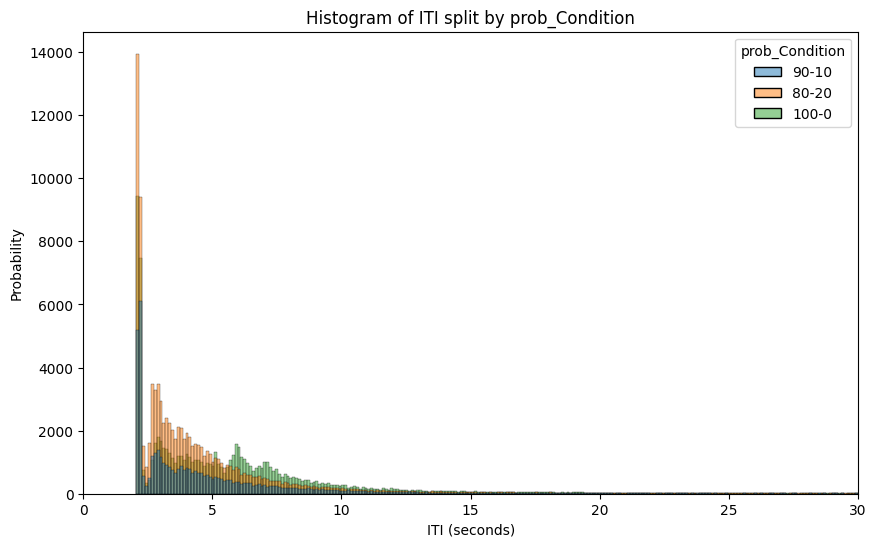

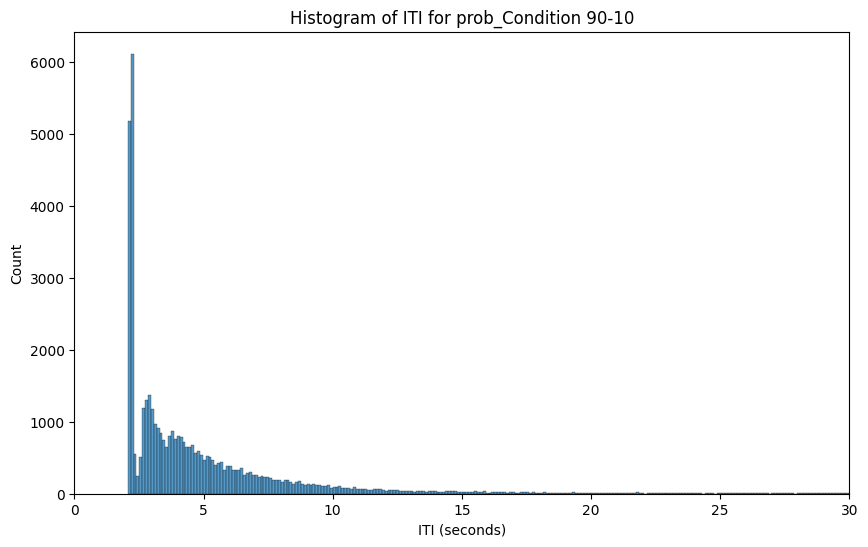

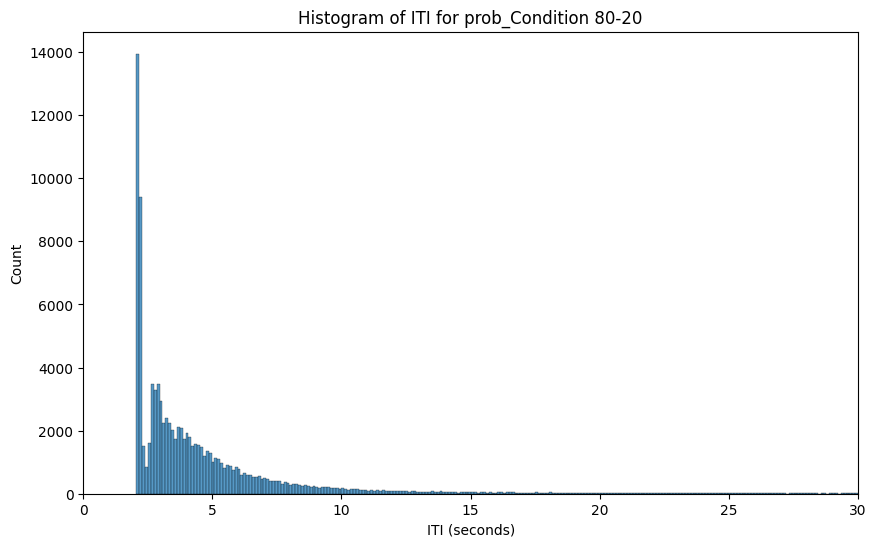

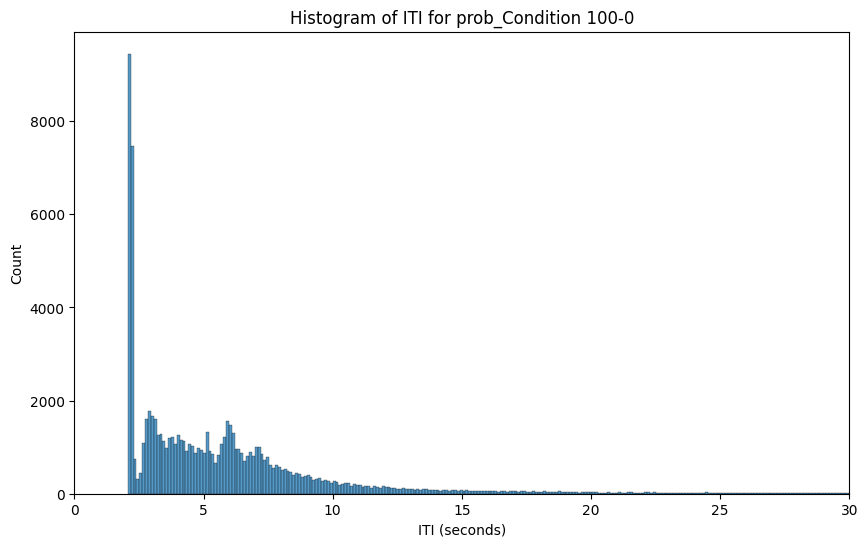

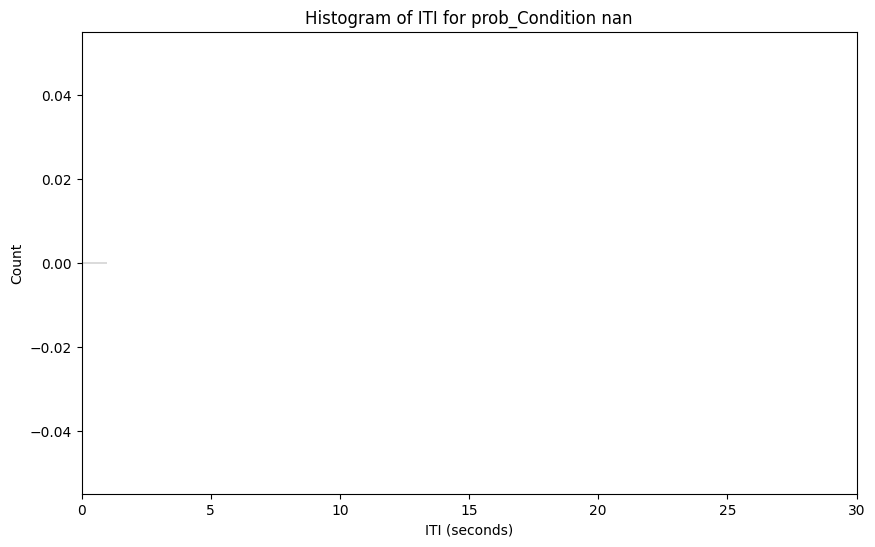

In [135]:
# filtered_df = tmp[tmp['ITI'] > 0]
# filtered_df = filtered_df[filtered_df['ITI'] < 30]
# filtered_df = filtered_df[filtered_df['prob_Condition'] != '100-100']
# filtered_df = filtered_df[filtered_df['prob_Condition'] != '80-80']

# Plot a histogram of the ITT split by 'prob_Condition' normalized for each prob_Condition
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_df, x='ITI', hue='prob_Condition',common_norm=True, bins=250)
plt.xlabel('ITI (seconds)')
plt.ylabel('Probability')
plt.title('Histogram of ITI split by prob_Condition')
plt.xlim(0, 30)
# plt.legend(title='prob_Condition')
plt.show()

# Plot a histogram of ITI for each Prob Condition, three different plots


for probs in filtered_df['prob_Condition'].unique():
    plt.figure(figsize=(10, 6))
    sns.histplot(data=filtered_df[filtered_df['prob_Condition'] == probs], x='ITI', bins=250)
    plt.xlabel('ITI (seconds)')
    plt.ylabel('Count')
    plt.title(f'Histogram of ITI for prob_Condition {probs}')
    plt.xlim(0, 30)
    plt.show()



In [187]:
tmp.columns.unique()

Index(['Trial', 'BlockCount', 'TrialWithinBlock', 'Block', 'Condition',
       'TrialError', 'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month',
       'Day', 'Hour', 'Minute', 'Second', 'CycleRate_1', 'CycleRate_2', 'Ver',
       'CodeTimes_1', 'CodeTimes_2', 'CodeTimes_3', 'CodeTimes_4',
       'CodeTimes_5', 'CodeTimes_6', 'CodeTimes_7', 'CodeNumbers_1',
       'CodeNumbers_2', 'CodeNumbers_3', 'CodeNumbers_4', 'CodeNumbers_5',
       'CodeNumbers_6', 'CodeNumbers_7', 'StartTimes', 'EndTimes',
       'reward_dur', 'EyeOffset_1', 'EyeOffset_2', 'Eye2Offset_1',
       'Eye2Offset_2', 'RewardVolume', 'RewardType', 'BlockLength',
       'RandomValue', 'Block_Prob', 'StimuliChosen', 'ProbReward', 'Reward',
       'Animal_Name', 'filename_part_0', 'filename_part_1', 'filename_part_2',
       'filename_part_3', 'filename_part_4', 'filename_part_5',
       'filename_part_6', 'TaskObject1_Type', 'TaskObject1_Size_1',
       'TaskObject1_Size_2', 'TaskObject1_Color_1', 'TaskObject1_Col

In [188]:
import pandas as pd

# Create a summary list to collect the data
summary_data = []

# Loop through each unique Animal_Name
for animal in tmp['Animal_Name'].unique():
    # Get the rows for the current animal
    animal_rows = tmp[tmp['Animal_Name'] == animal]
    
    # Loop through each unique Session_ID for this animal
    for session_id in animal_rows['Session_ID'].unique():
        # Get the rows for the current session_id
        session_rows = animal_rows[animal_rows['Session_ID'] == session_id]
        
        # Calculate the number of "Reward" and "Accuracy"
        num_reward = len(session_rows[session_rows['Reward'] == 'Rewarded'])
        num_trials = len(session_rows)  
        num_blocks = len(session_rows['Block'].unique())
        num_accuracy = num_reward / len(session_rows) if len(session_rows) > 0 else 0
        avg_blocklength = (session_rows['BlockLength'].mean() if 'BlockLength' in session_rows.columns else 0)  
        avg_ITI = (session_rows['ITI'].mean() if 'ITI' in session_rows.columns else 0)
        median_ITI = (session_rows['ITI'].median() if 'ITI' in session_rows.columns else 0)
        mode_ITI = (session_rows['ITI'].mode()[0] if not session_rows['ITI'].mode().empty else 0)
        Task_type = session_rows['Task_Type']

        # Get the prob_Condition for this session_id (assuming prob_Condition is already created)
        prob_condition = session_rows['prob_Condition'].iloc[0]  # Assuming it's the same for all rows in the session
        
        # Append the data as a dictionary to the summary list
        summary_data.append({
            'Animal_Name': animal,
            'Session_ID': session_id,
            'Task_type': Task_type,
            'prob_Condition': prob_condition,
            'Num_Reward': num_reward,
            'Num_Trials': num_trials,
            'Num_Blocks': num_blocks,
            'Avg_BlockLength': avg_blocklength,
            'Avg_ITI': avg_ITI,
            'Median_ITI': median_ITI,
            'Mode_ITI': mode_ITI,
            'Num_Accuracy': num_accuracy
        })

# Convert the list of dictionaries into a DataFrame
summary_df = pd.DataFrame(summary_data)

# Save the summary DataFrame to a CSV file (optional)
# summary_file_name = f'summary_{file_name}'
# summary_file_path = os.path.join(folder_path, summary_file_name)
# summary_df.to_csv(summary_file_path, index=False)
# print(f"Summary CSV saved to: {summary_file_path}")

# Print the summary DataFrame
print(summary_df)








     Animal_Name            Session_ID  \
0          Fiona      2024-03-06_Fiona   
1          Fiona      2022-02-17_Fiona   
2          Fiona      2022-02-10_Fiona   
3          Fiona      2021-11-05_Fiona   
4          Fiona      2021-11-02_Fiona   
...          ...                   ...   
1034   Sunflower  2024-01-12_Sunflower   
1035   Sunflower  2023-08-07_Sunflower   
1036   Sunflower  2023-08-31_Sunflower   
1037   Sunflower  2022-06-30_Sunflower   
1038   Sunflower  2023-11-13_Sunflower   

                                              Task_type prob_Condition  \
0     0      Reversal
1      Reversal
2      Reversa...          90-10   
1     336    WhereTask
337    WhereTask
338    Where...          80-20   
2     837     WhereTask
838     WhereTask
839     Wh...          80-20   
3     1210    WhereTask
1211    WhereTask
1212    Wh...          100-0   
4     1644    WhereTask
1645    WhereTask
1646    Wh...          100-0   
...                                                

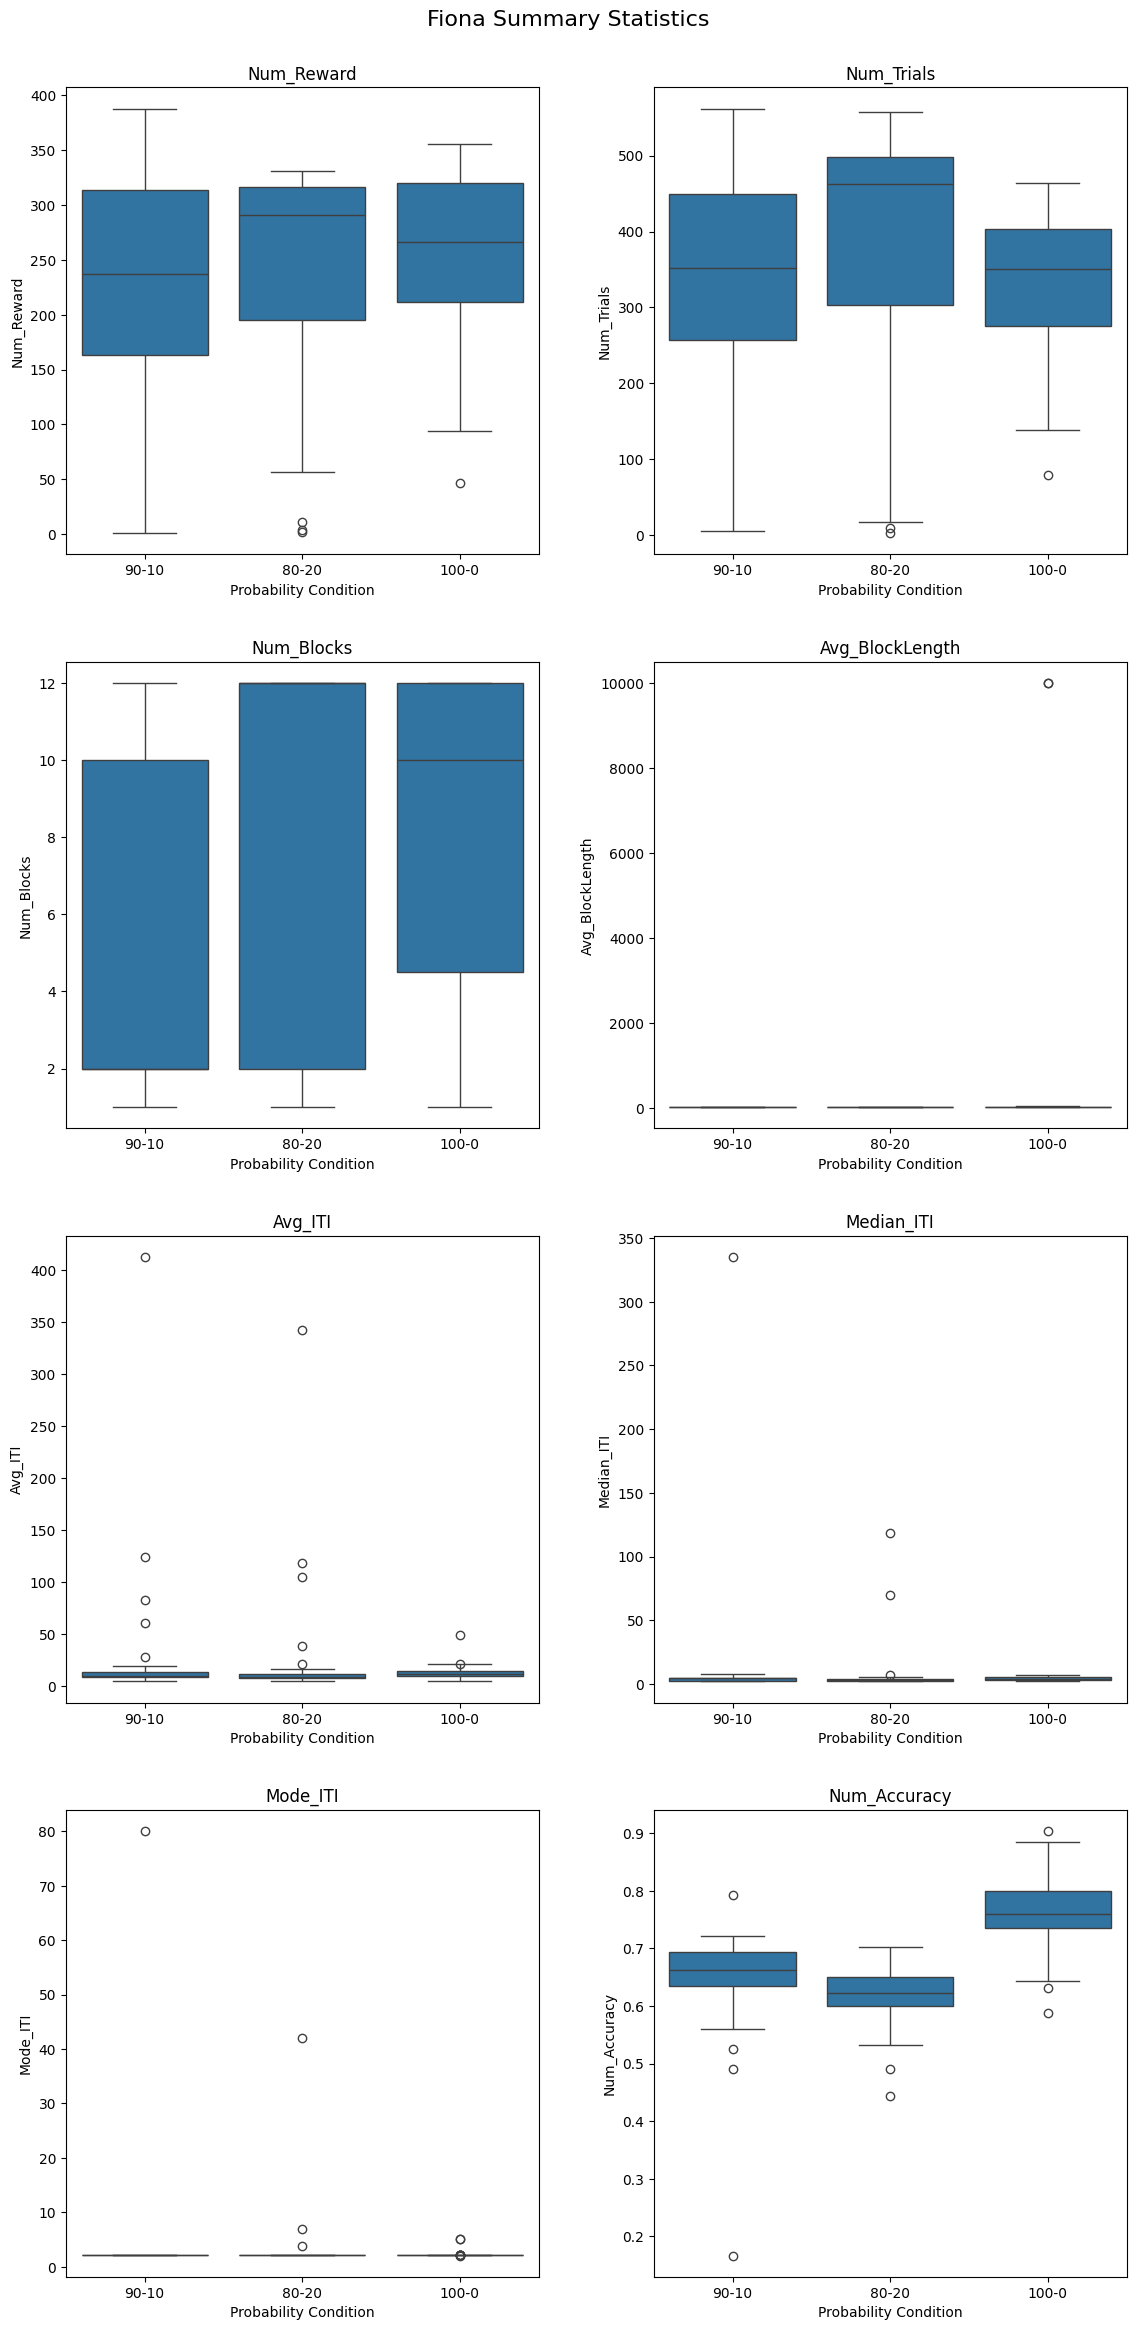

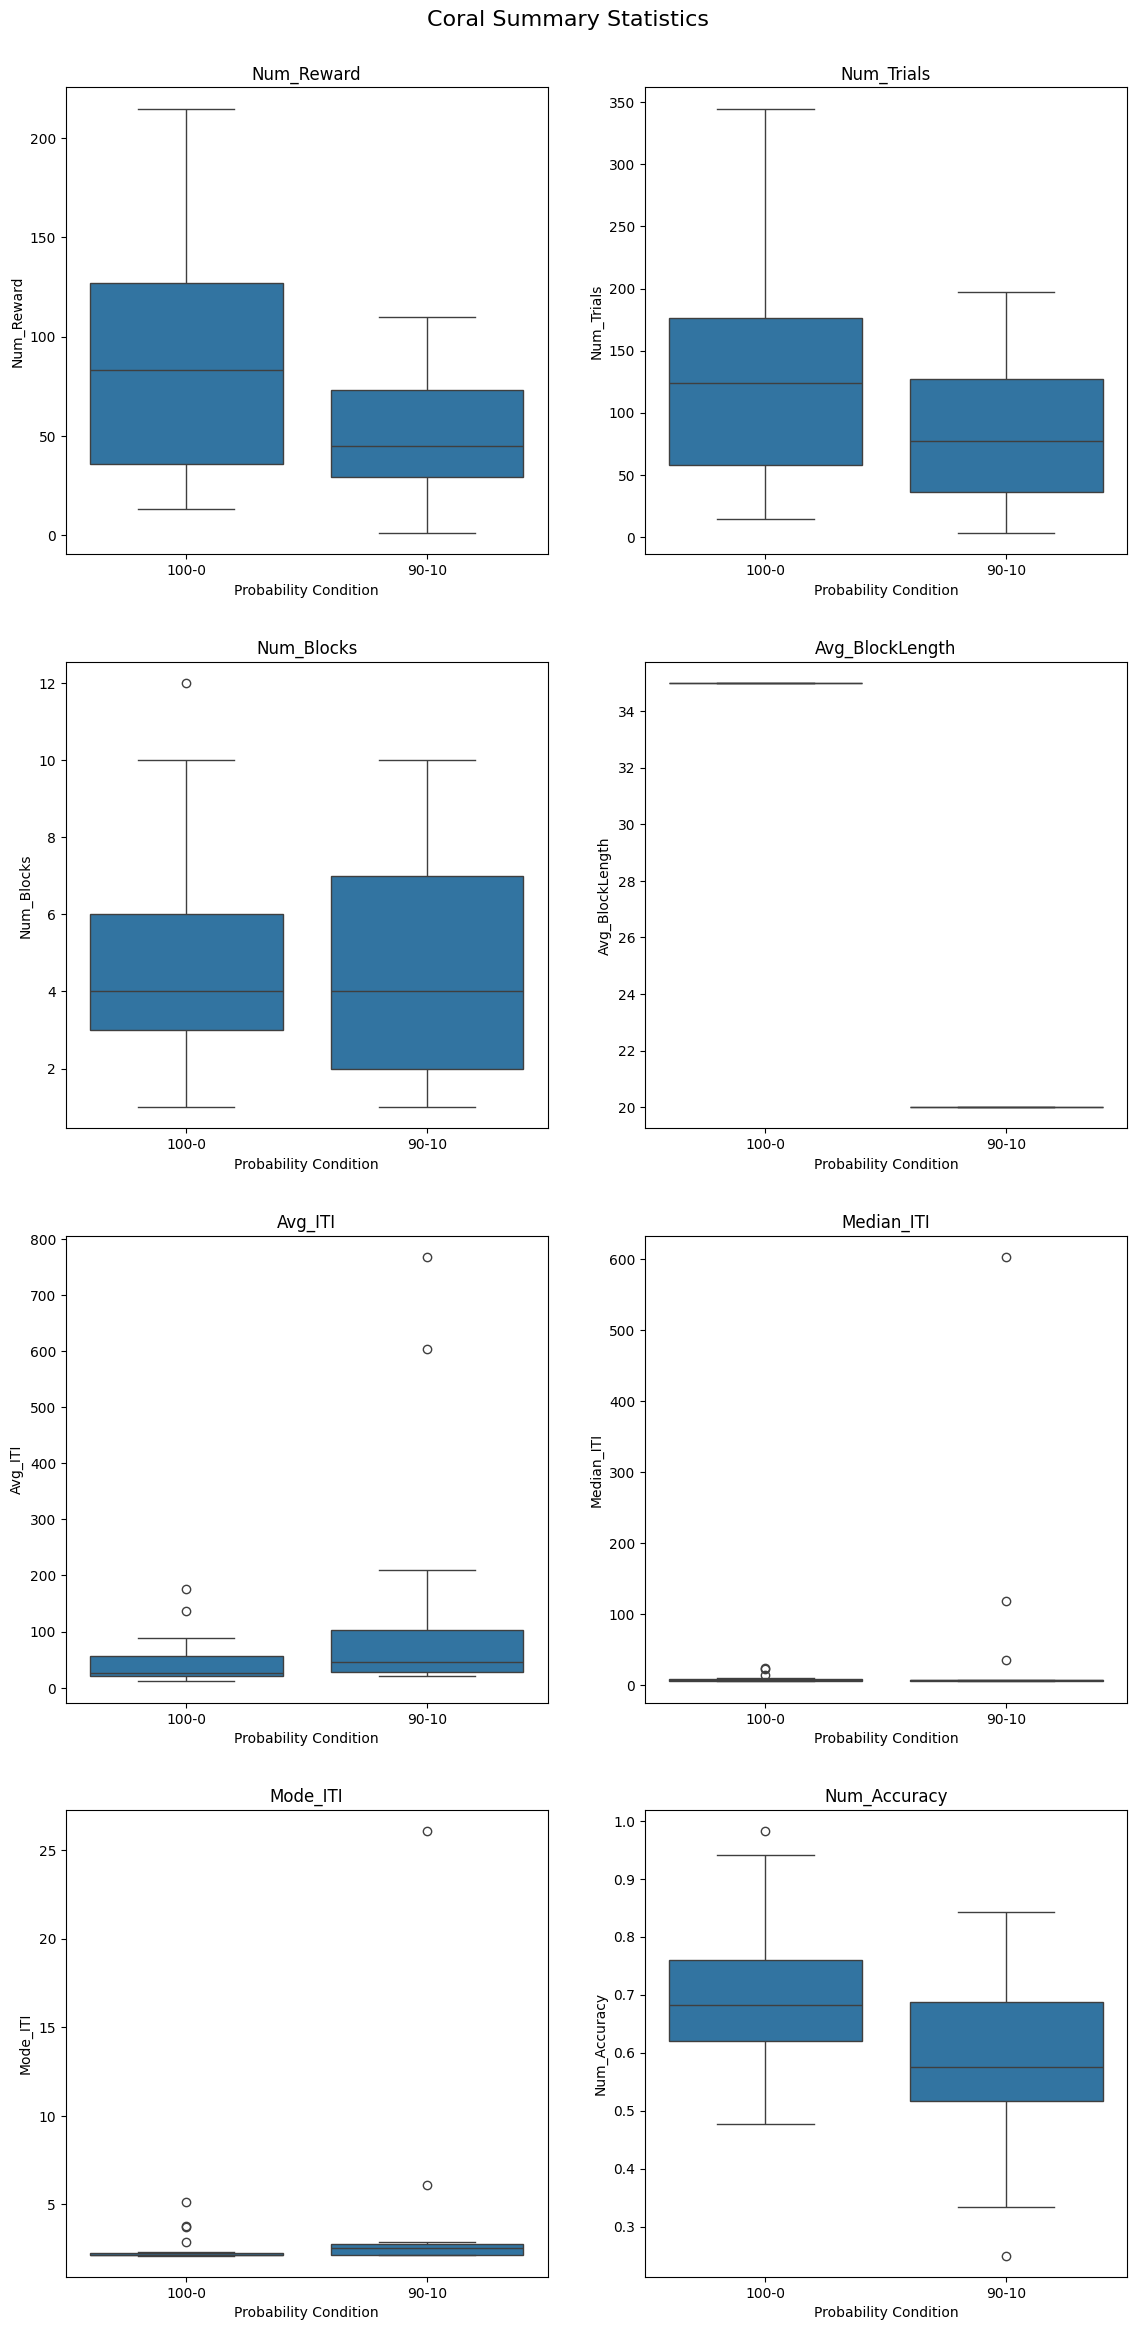

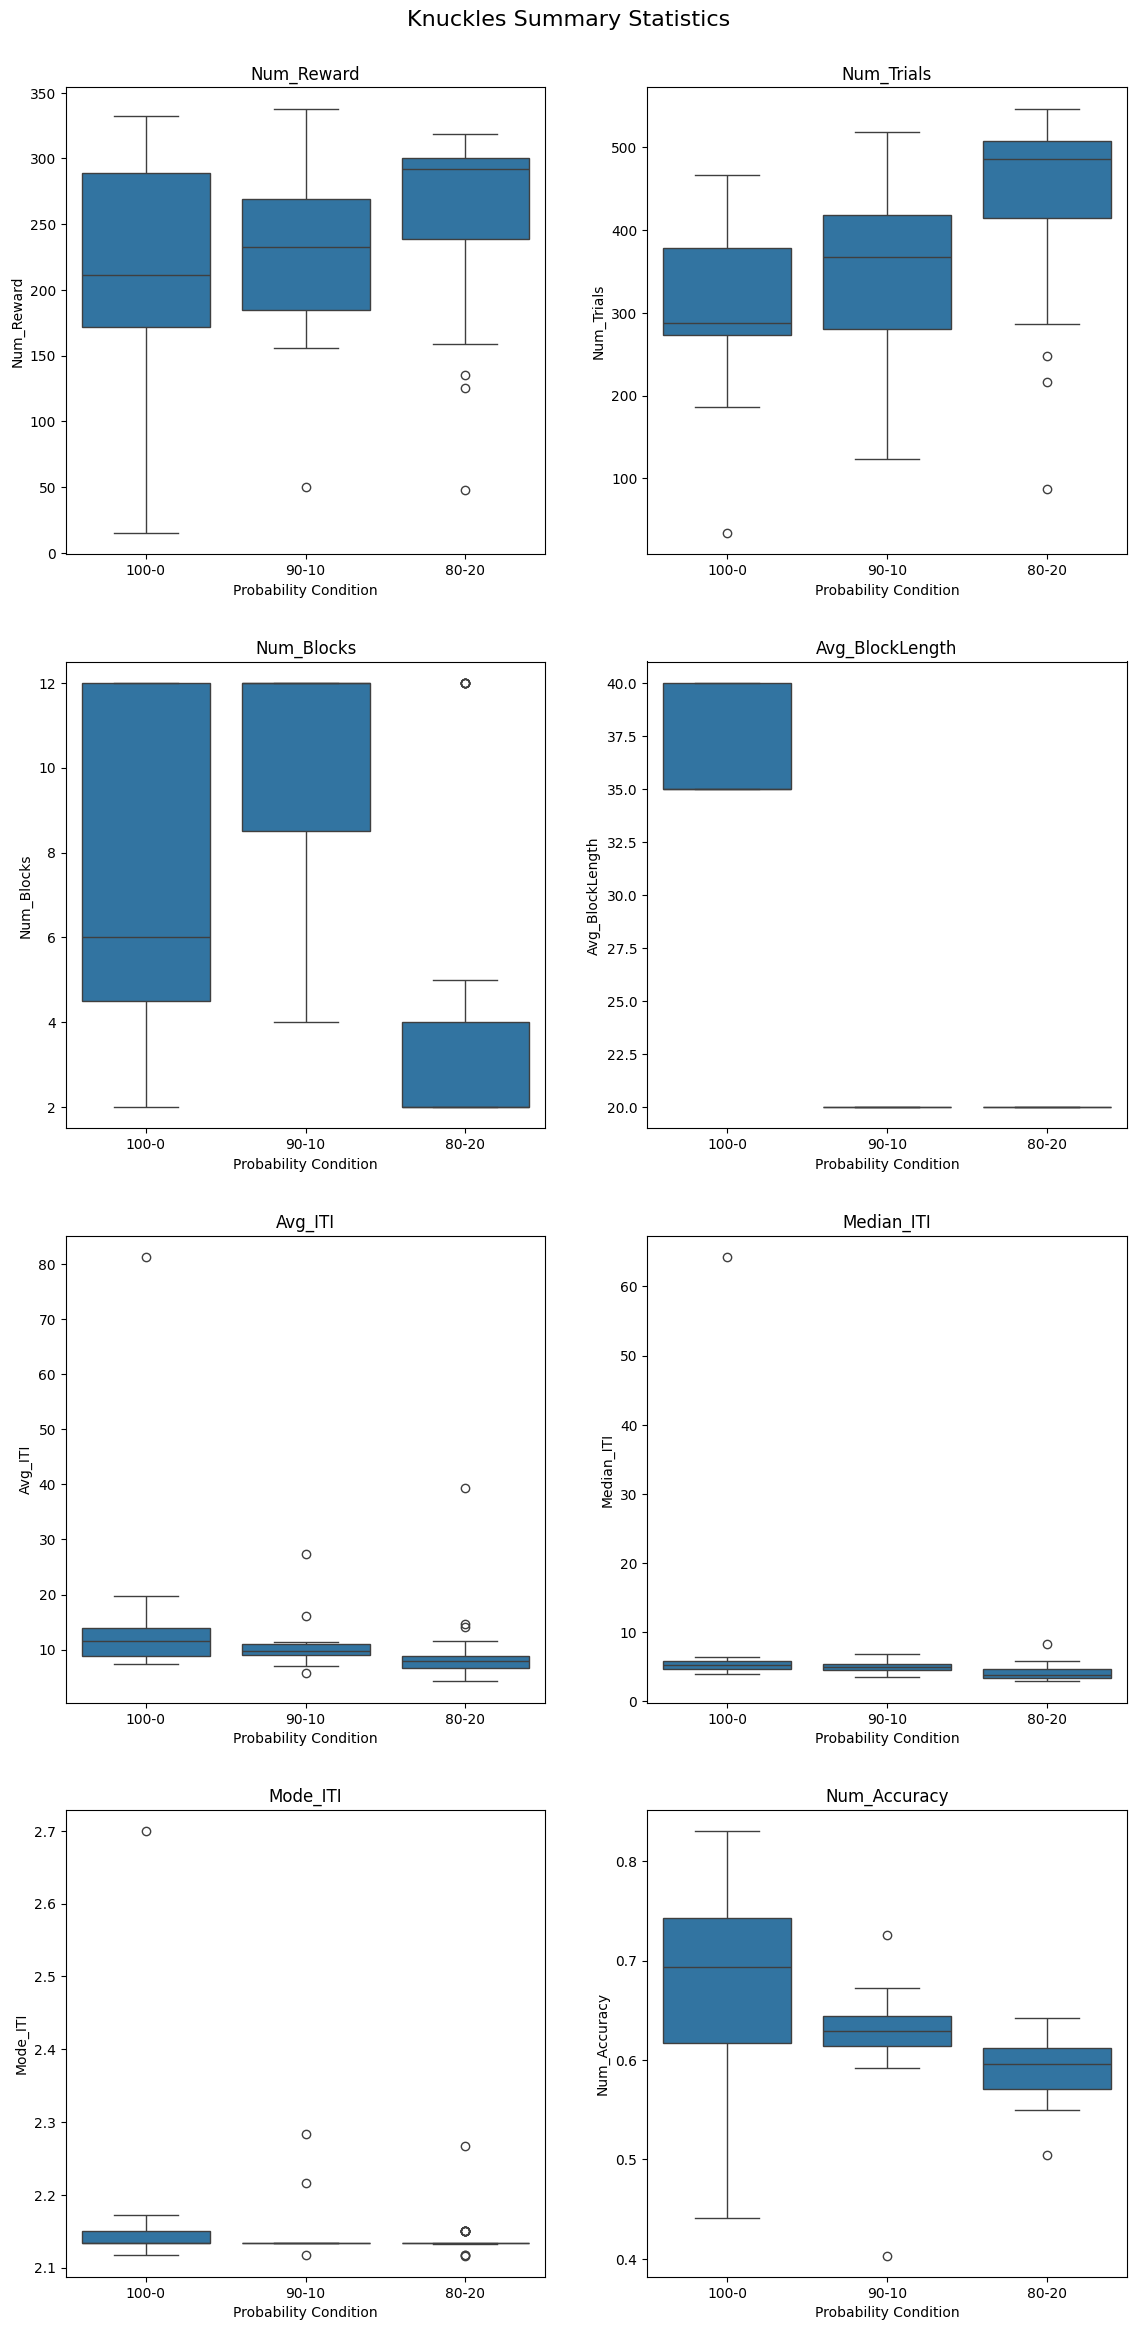

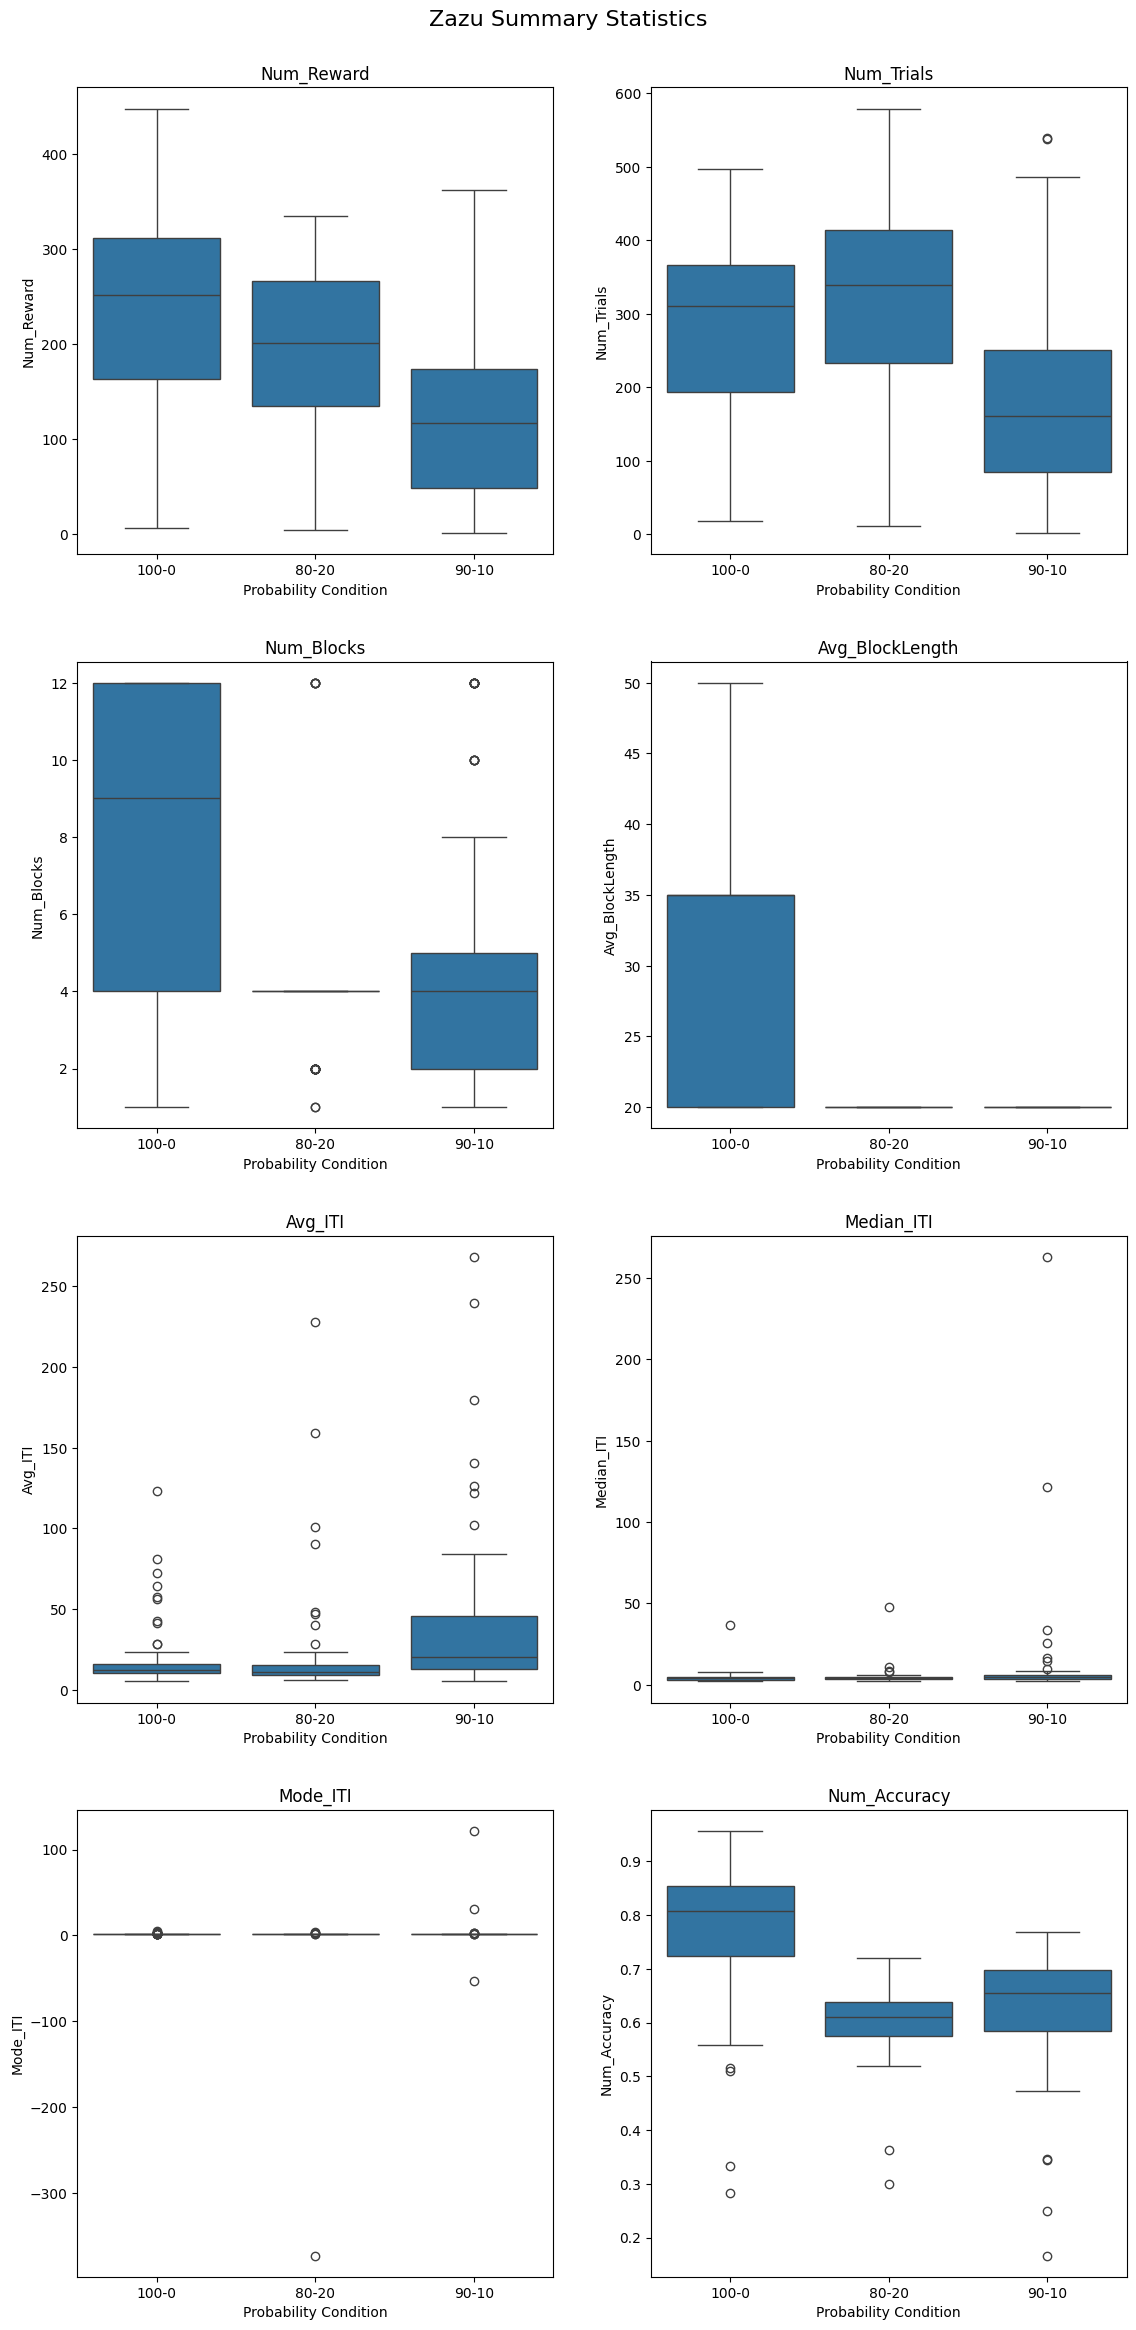

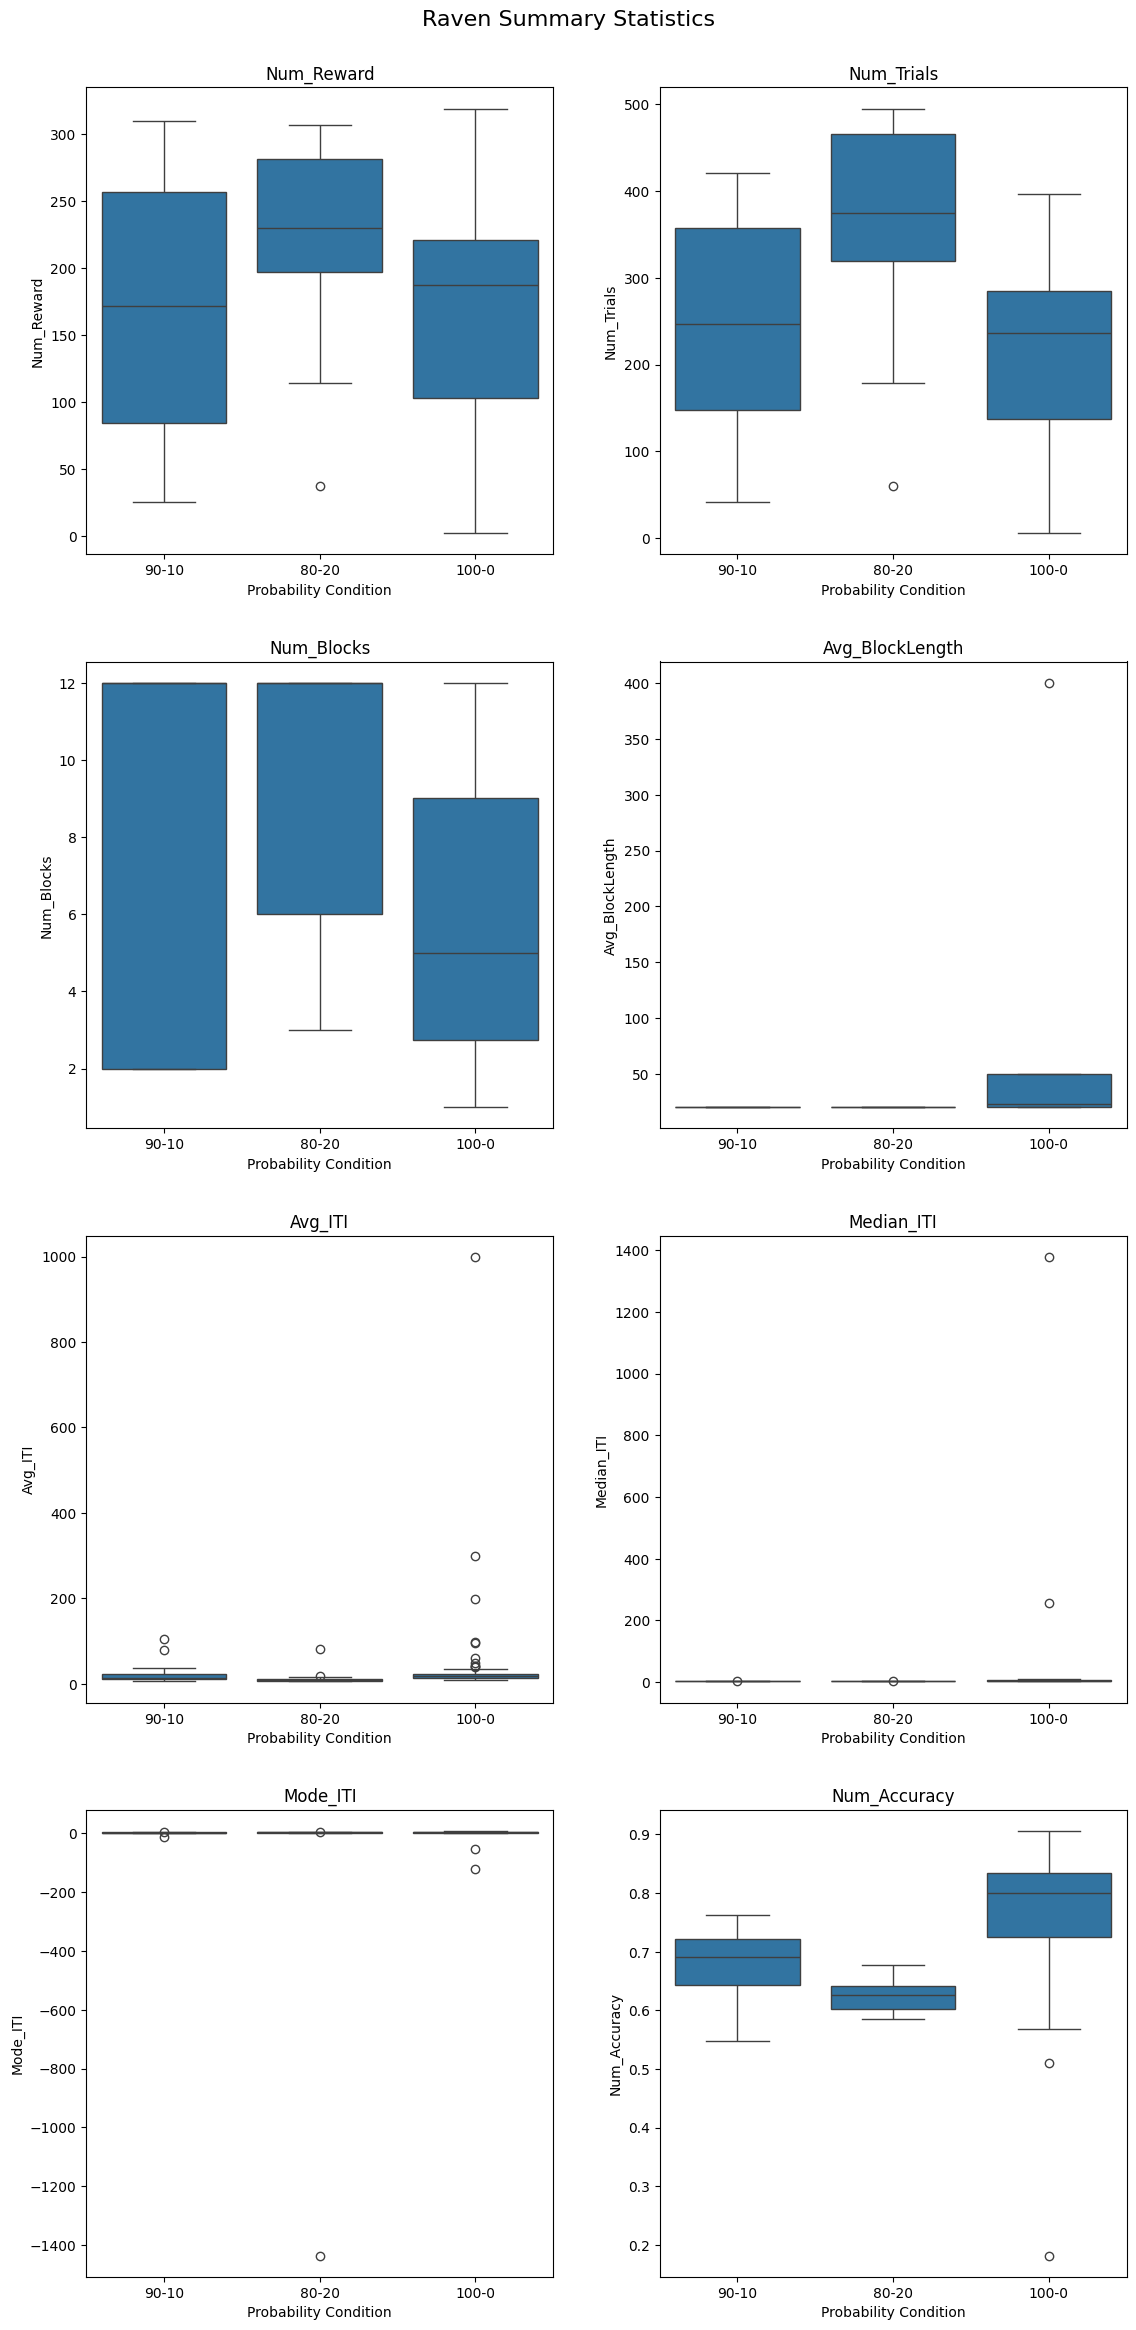

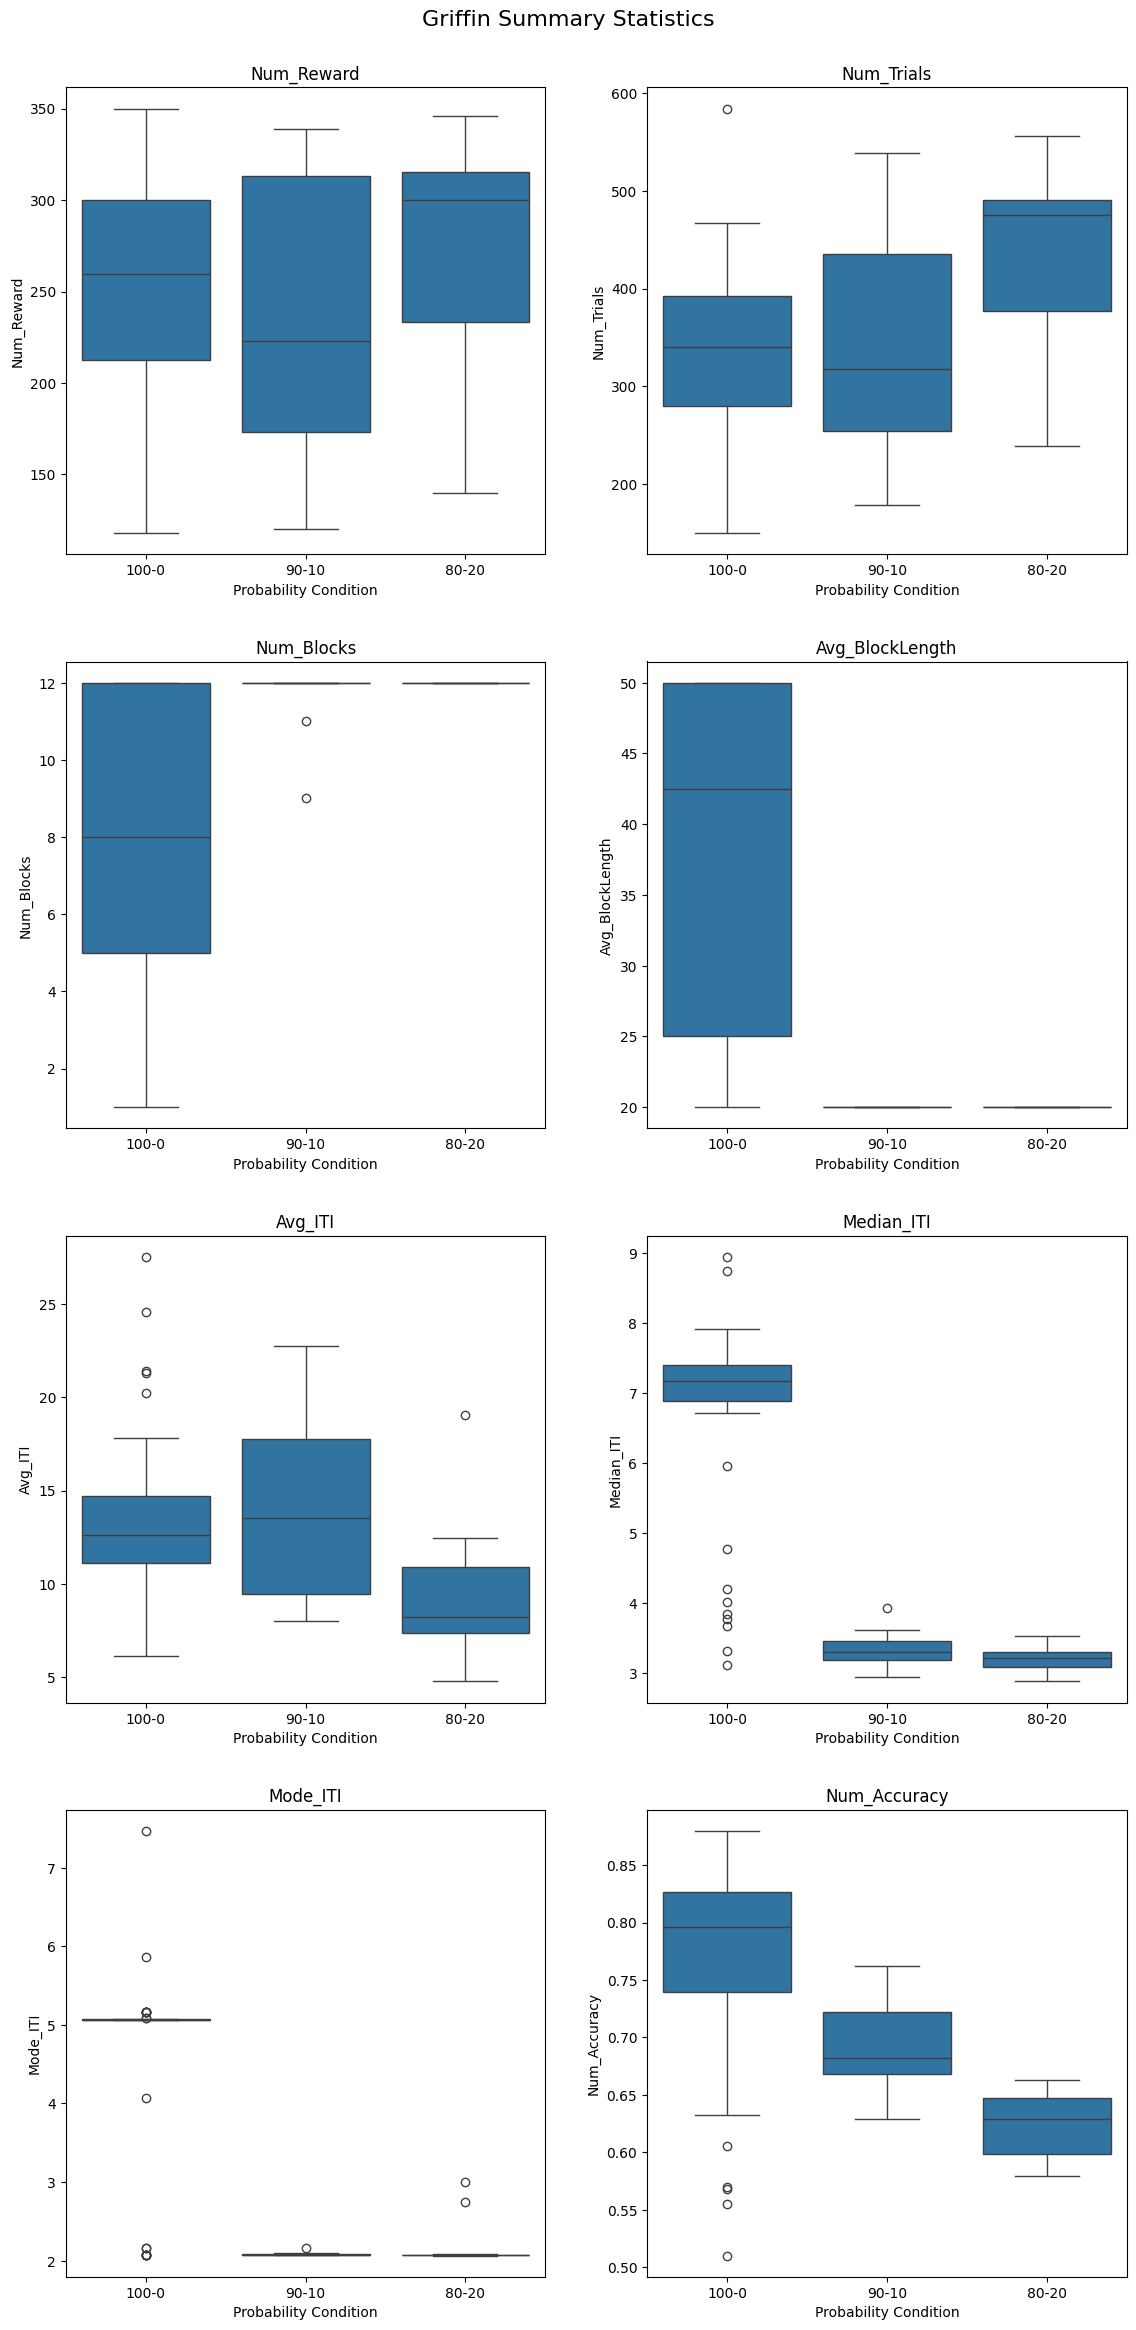

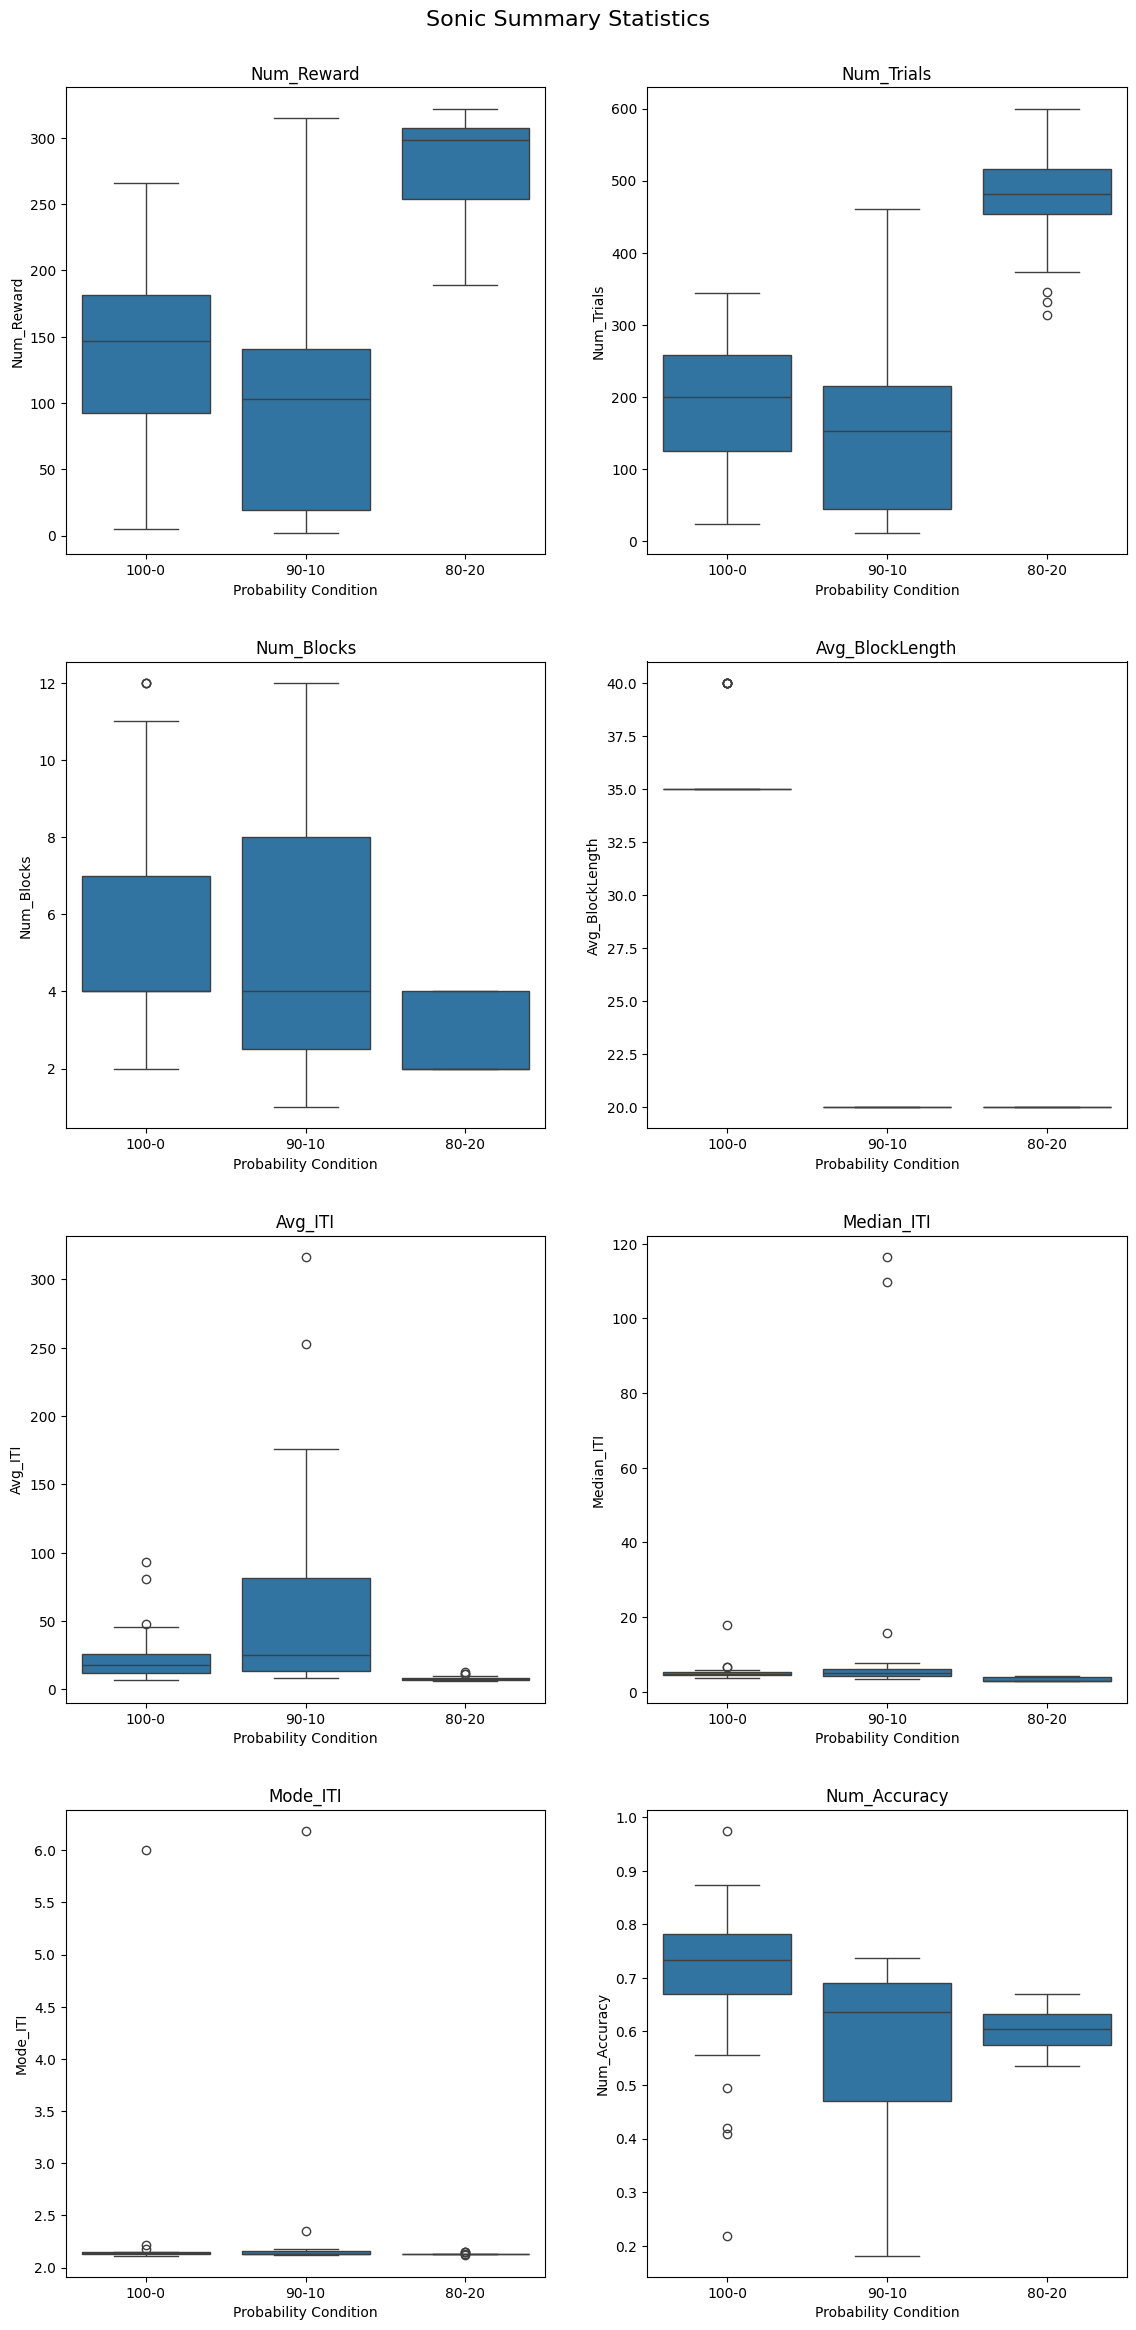

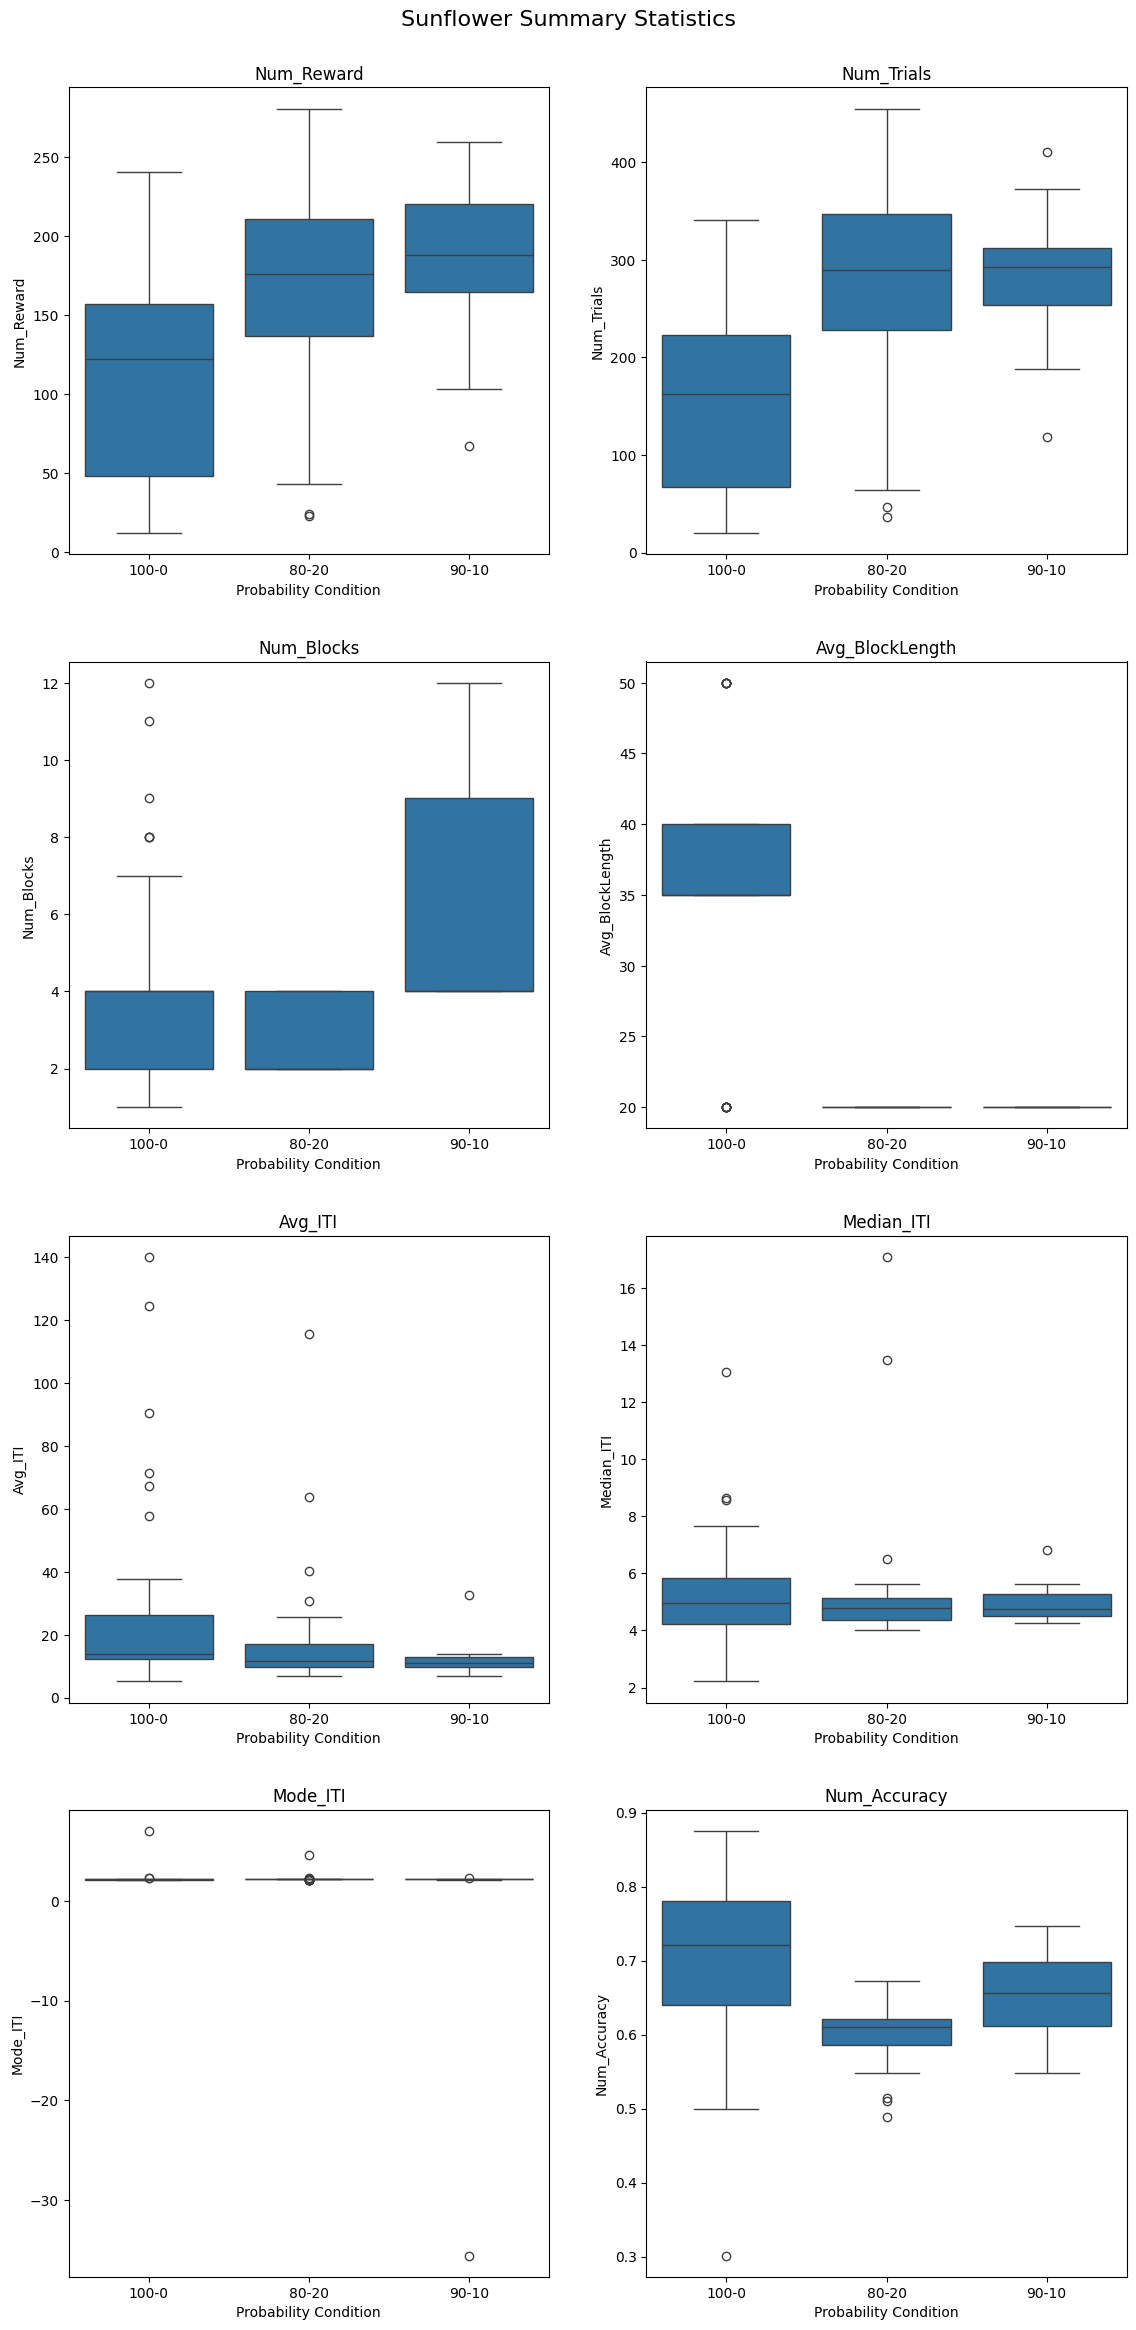

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assuming summary_df is already defined and contains the necessary data
summary_df = summary_df[summary_df['prob_Condition'] != '80-80']
summary_df = summary_df[summary_df['prob_Condition'] != '100-100']

# Create a directory for the plots
plots_dir = os.path.join(folder_path, 'plots')
os.makedirs(plots_dir, exist_ok=True)

# Loop through each unique Animal_Name
for animal in summary_df['Animal_Name'].unique():
    animal_summary = summary_df[summary_df['Animal_Name'] == animal]

    # List of variables to plot
    variables = ['Num_Reward', 'Num_Trials', 'Num_Blocks', 'Avg_BlockLength', 'Avg_ITI', 'Median_ITI', 'Mode_ITI', 'Num_Accuracy']

    # Calculate the number of rows and columns for the subplots
    n_vars = len(variables)
    n_cols = 2  # You can adjust the number of columns as needed
    n_rows = (n_vars + n_cols - 1) // n_cols  # This ensures you have enough rows to fit all variables

    # Create subplots with the appropriate number of rows and columns
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(12, 6 * n_rows))

    # Flatten the axs array in case there are multiple rows/columns
    axs = axs.flatten()

    # Title for the overall figure
    fig.suptitle(f'{animal} Summary Statistics', fontsize=16)

    # Loop through the variables and plot each one in its respective subplot
    for i, var in enumerate(variables):
        sns.boxplot(data=animal_summary, x='prob_Condition', y=var, ax=axs[i])
        axs[i].set_title(var)
        axs[i].set_xlabel('Probability Condition')
        axs[i].set_ylabel(var)

    # Adjust layout to avoid overlap
    fig.tight_layout(pad=3.0)

    # Save the figure as a PNG file
    file_name = f'{animal}_summary_statistics.png'
    file_path = os.path.join(plots_dir, file_name)
    plt.savefig(file_path)

    # Display the plot
    plt.show()

    # Close the plot to save memory
    plt.close(fig)


In [173]:

# Function to categorize the task based on the filename parts
def categorize_task(row):
    # Concatenate all filename parts to form the full filename
    filename = ' '.join([str(row[f'filename_part_{i}']) for i in range(7)])

    # Search for specific patterns and assign task type
    if re.search(r'Reversal', filename):
        return 'Reversal'
    elif re.search(r'Where', filename):
        return 'WhereTask'
    elif re.search(r'Shaping', filename):
        return 'Shaping'
    elif re.search(r'SetChanges', filename):
        return 'Reversal_SetChanges'
    else:
        return 'What Task'

# Apply the function to create a new column with the task label
tmp['Task_Type'] = tmp.apply(categorize_task, axis=1)

# Display the DataFrame with the task labels
print(tmp)

        Trial  BlockCount  TrialWithinBlock  Block  Condition  TrialError  \
0           1           1                 1      1          1           0   
1           2           1                 2      1          1           0   
2           3           1                 3      1          1           0   
3           4           1                 4      1          1           6   
4           5           1                 5      1          1           0   
...       ...         ...               ...    ...        ...         ...   
310995    338          17                18      1          1           0   
310996    339          17                19      1          1           0   
310997    340          17                20      1          1           0   
310998    341          18                 1      2          2           0   
312209      1           1                 1     12         12           6   

        ReactionTime  AbsoluteTrialStartTime  Year  Month  ...  \
0        

In [183]:
# length of tmp when Task_Type is 'Reversal'
len(tmp[tmp['Task_Type'] == 'What Task'])

# what are the prob_Condition values when Task_Type is 'What Task'
tmp[tmp['Task_Type'] == 'What Task']['prob_Condition'].unique()

# lenght of trials where Task_Type is 'What Task' and prob_Condition is '100-0' 
len(tmp[(tmp['Task_Type'] == 'What Task') & (tmp['prob_Condition'] == '100-0')])

#  For Task_type 'What Task' make the  prob_Condition equal to '100-0'
tmp.loc[tmp['Task_Type'] == 'What Task', 'prob_Condition'] = '100-0'    


In [184]:
# Rows where Task_Type is 'Other'
print(len(tmp[tmp['Task_Type'] == 'Other Task']))

# # #add filename column that jjoins all filename parts 
# # tmp['filename'] = tmp.apply(lambda x: ' '.join([str(x[f'filename_part_{i}']) for i in range(7)]), axis=1)

# # for the rows where Task_Type is 'Other Task', store filenames and then print the unique filenames
# other_task_rows = tmp[tmp['Task_Type'] == 'Other Task']
# unique_filenames = other_task_rows['filename'].unique()
# print(unique_filenames)



# # Numbers of Rows where the Task_Type is 'Reversal' and split by prob_Condition
for prob in tmp['prob_Condition'].unique():
    print(f"Prob Condition: {prob}, Count: {len(tmp[(tmp['Task_Type'] == 'Reversal') & (tmp['prob_Condition'] == prob)])}")
# Numbers of Rows where the Task_Type is 'WhereTask' and split by prob_Condition
for prob in tmp['prob_Condition'].unique():
    print(f"Prob Condition: {prob}, Count: {len(tmp[(tmp['Task_Type'] == 'WhereTask') & (tmp['prob_Condition'] == prob)])}")
# Numbers of Rows where the Task_Type is 'Shaping' and split by prob_Condition
for prob in tmp['prob_Condition'].unique():
    print(f"Prob Condition: {prob}, Count: {len(tmp[(tmp['Task_Type'] == 'What Task') & (tmp['prob_Condition'] == prob)])}")




0
Prob Condition: 90-10, Count: 25233
Prob Condition: 80-20, Count: 62054
Prob Condition: 100-0, Count: 15315
Prob Condition: 80-80, Count: 11
Prob Condition: 100-100, Count: 2
Prob Condition: nan, Count: 0
Prob Condition: 90-10, Count: 22542
Prob Condition: 80-20, Count: 40318
Prob Condition: 100-0, Count: 68748
Prob Condition: 80-80, Count: 0
Prob Condition: 100-100, Count: 30
Prob Condition: nan, Count: 0
Prob Condition: 90-10, Count: 0
Prob Condition: 80-20, Count: 0
Prob Condition: 100-0, Count: 74356
Prob Condition: 80-80, Count: 0
Prob Condition: 100-100, Count: 0
Prob Condition: nan, Count: 0


In [190]:
for prob in tmp['prob_Condition'].unique():
    print(f"Prob Condition: {prob}, Count: {len(tmp[(tmp['Task_Type'] == 'Reversal') & (tmp['prob_Condition'] == prob)])}")
    # make a new dataframe with only the rows where Task_Type is 'Reversal' and prob_Condition is prob
    prob_df = tmp[(tmp['Task_Type'] == 'Reversal') & (tmp['prob_Condition'] == prob)]
    
    # For each unique Session_ID, calcuate the probability of selecting the high port at each trial at each "blocktrial" position
    for session_id in prob_df['Session_ID'].unique():
        # Get the rows for the current session_id
        session_rows = prob_df[prob_df['Session_ID'] == session_id]
        
        # Get the unique blocktrial positions
        blocktrial_positions = session_rows['BlockTrial'].unique()
        
        # For each blocktrial position, calculate the probability of selecting the high port
        for position in blocktrial_positions:
            position_rows = session_rows[session_rows['BlockTrial'] == position]
            prob_high_port = len(position_rows[position_rows['Decision'] == 1]) / len(position_rows) if len(position_rows) > 0 else 0
            
            # Store the result in a new column
            prob_df.loc[position_rows.index, 'Prob_High_Port'] = prob_high_port


Prob Condition: 90-10, Count: 25233
Number of rows in prob_df: 25233
Prob Condition: 80-20, Count: 62054
Number of rows in prob_df: 62054
Prob Condition: 100-0, Count: 15315
Number of rows in prob_df: 15315
Prob Condition: 80-80, Count: 11
Number of rows in prob_df: 11
Prob Condition: 100-100, Count: 2
Number of rows in prob_df: 2
Prob Condition: nan, Count: 0
Number of rows in prob_df: 0


In [189]:
# # save tmp to csv as preprocessed_master_merged_data.csv
# preprocessed_file_name = f'preprocessed_{file_name}'
# preprocessed_file_path = os.path.join(folder_path, preprocessed_file_name)
# tmp.to_csv(preprocessed_file_path, index=False)
# print(f"Preprocessed CSV saved to: {preprocessed_file_path}")


Preprocessed CSV saved to: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/preprocessed_Sunflower_summary_statistics.png


In [185]:
# Total number of trials for each 'prob_condition'
total_trials = summary_df.groupby('prob_Condition')['Num_Trials'].sum().reset_index()
total_trials


,prob_Condition,Num_Trials
0,100-0,89610
1,80-20,102372
2,90-10,47775


In [9]:
# print(f'Data contains the following columns: {df_master.columns.unique()}')

print(f'Data contains the following treatments: {df_master.ProbReward.unique()}')

print(f'Data contains the following Conditions: {df_master.BlockLength.unique()}')

print(f'Data contains the following Animal Name: {df_master.Animal_Name.unique()}')

Data contains the following treatments: [0.9 0.1 0.8 0.2 0.  1.  nan]
Data contains the following Conditions: [  20.   30.   35.   40. 9999.   25.   50.   nan  500.]
Data contains the following Animal Name: ['Fiona' 'Coral' 'Knuckles' 'Zazu' 'Raven' 'Griffin' 'Sonic' 'Sunflower'
 nan]


In [11]:
# Define the pattern you want to match
# pattern = 'WhereBlocks1'
# Use regex to filter rows
import re

df = df_master.copy()
y_df_filtered_1 = df[df.apply(lambda row: any(re.search('WhereBlocks1', str(cell)) for cell in row), axis=1)]
y_df_filtered_2 = df[df.apply(lambda row: any(re.search('WhereBlocks2', str(cell)) for cell in row), axis=1)]
y_df_filtered_3 = df[df.apply(lambda row: any(re.search('WhereBlocks3', str(cell)) for cell in row), axis=1)]

y_df_reversal_1 = df[df.apply(lambda row: any(re.search('Reversal1', str(cell)) for cell in row), axis=1)]
y_df_reversal_2 = df[df.apply(lambda row: any(re.search('Reversal2', str(cell)) for cell in row), axis=1)]
y_df_reversal_3 = df[df.apply(lambda row: any(re.search('Reversal3', str(cell)) for cell in row), axis=1)]



In [57]:
# y_df_reversal_3 - filter for a specific Animal Name 
# temp = y_df_reversal_3[y_df_reversal_3['Animal_Name'] == 'Sonic']
temp = df_master.copy()
# Create a 'Session ID' which includes the date and Animal Name

# First need to make 'Date' from "Year", "Month", "Day"
temp['Date'] = pd.to_datetime(temp[['Year', 'Month', 'Day']])
temp['Date']


temp['Session_ID'] = temp['Date'].astype(str) + '_' + temp['Animal_Name']
temp['Session_ID']


0        2024-03-06_Fiona
1        2024-03-06_Fiona
2        2024-03-06_Fiona
3        2024-03-06_Fiona
4        2024-03-06_Fiona
               ...       
95033    2023-02-07_Fiona
95034    2023-02-07_Fiona
95035    2023-02-07_Fiona
95036    2023-02-07_Fiona
95037    2023-02-07_Fiona
Name: Session_ID, Length: 95038, dtype: object

In [58]:

#  Loop through temp and print the length of each unique 'Session ID'
for session_id in temp['Session_ID'].unique():
    print(f'{session_id}: {len(temp[temp["Session_ID"] == session_id])}')

2024-03-06_Fiona: 672
2022-02-17_Fiona: 1002
2022-02-10_Fiona: 746
nan: 0
2022-04-12_Fiona: 836
2022-02-18_Fiona: 984
2022-02-11_Fiona: 730
2022-04-14_Fiona: 884
2022-04-25_Fiona: 994
2022-04-22_Fiona: 578
2022-03-08_Fiona: 520
2024-02-21_Fiona: 552
2022-05-03_Fiona: 402
2022-05-04_Fiona: 526
2022-03-31_Fiona: 850
2024-02-20_Fiona: 540
2024-02-27_Fiona: 632
2024-02-29_Fiona: 828
2022-03-07_Fiona: 482
2022-05-05_Fiona: 770
2022-05-02_Fiona: 864
2023-01-19_Fiona: 18
2023-01-26_Fiona: 332
2022-05-16_Fiona: 1114
2023-01-10_Fiona: 214
2022-05-18_Fiona: 826
2024-02-05_Fiona: 602
2022-01-26_Fiona: 996
2022-01-21_Fiona: 1074
2024-02-02_Fiona: 496
2023-01-11_Fiona: 36
2022-05-17_Fiona: 342
2023-01-27_Fiona: 610
2023-01-20_Fiona: 22
2022-05-10_Fiona: 580
2022-01-20_Fiona: 990
2022-01-18_Fiona: 1032
2022-04-07_Fiona: 852
2024-03-25_Fiona: 684
2024-01-26_Fiona: 330
2024-01-19_Fiona: 508
2022-04-08_Fiona: 964
2022-04-06_Fiona: 912
2023-02-03_Fiona: 604
2022-04-01_Fiona: 906
2024-03-12_Fiona: 666
20

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_3091/1505911521.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp2['ITI'] = temp2['AbsoluteTrialStartTime'].diff()


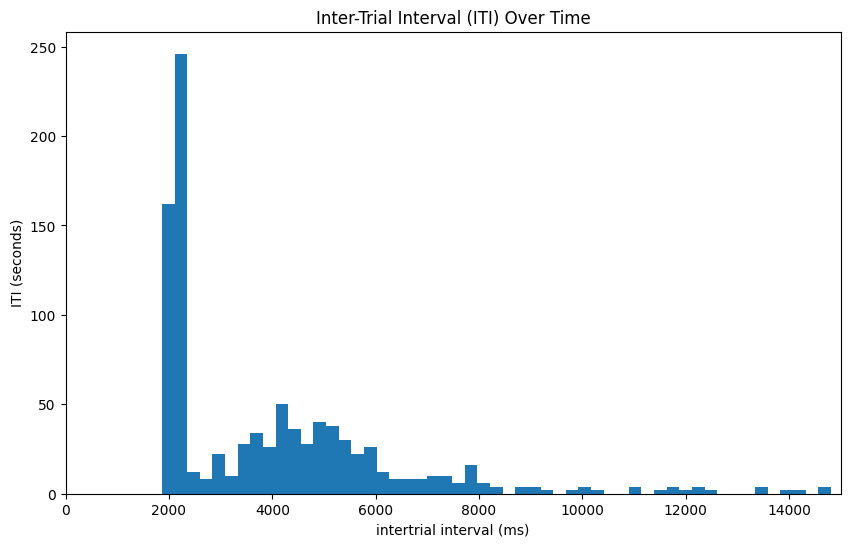

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

temp2 = temp[temp['Session_ID'] == '2022-04-25_Fiona']

temp2
# Calculate the Inter-Trial Interval (ITI)
temp2['ITI'] = temp2['AbsoluteTrialStartTime'].diff()
# temp2['ITI'] = temp2['ITI'].fillna(0)  # Fill NaN values with 0

#  Plot the ITI based on 'AbsoluteTrialStartTime'
plt.figure(figsize=(10, 6))
plt.hist(temp2['ITI'], bins=20000)
plt.title('Inter-Trial Interval (ITI) Over Time')
plt.xlabel('intertrial interval (ms)')
plt.ylabel('ITI (seconds)')
plt.xlim(0, 15000)
plt.show()




In [61]:
temp3 = temp2.drop_duplicates()

temp3
# fiona = df.copy()
# zazu = df.copy()
# sunflower = df.copy()
# knuckles = df.copy()
# sonic = df.copy()

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,SkippedFrameTimeInfo_2054,SkippedFrameTimeInfo_2055,SkippedFrameTimeInfo_2056,SkippedFrameTimeInfo_2057,SkippedFrameTimeInfo_2058,SkippedFrameTimeInfo_2059,SkippedFrameTimeInfo_2060,Date,Session_ID,ITI
4702,1,1,1,5,5,6,NaN,0.000000e+00,2022,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,2022-04-25_Fiona,NaN
4703,2,1,2,5,5,0,NaN,1.360519e+05,2022,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,2022-04-25_Fiona,136051.9373
4704,3,1,3,5,5,0,NaN,1.431673e+05,2022,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,2022-04-25_Fiona,7115.3909
4705,4,1,4,5,5,6,NaN,1.549159e+05,2022,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,2022-04-25_Fiona,11748.5652
4706,5,1,5,5,5,0,NaN,1.627993e+05,2022,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,2022-04-25_Fiona,7883.3704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52713,493,25,13,5,5,6,NaN,3.974564e+06,2022,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,2022-04-25_Fiona,823675.2783
52714,494,25,14,5,5,6,NaN,4.051219e+06,2022,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,2022-04-25_Fiona,76655.1063
52715,495,25,15,5,5,0,NaN,4.053302e+06,2022,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,2022-04-25_Fiona,2083.1567
52716,496,25,16,5,5,0,NaN,4.057768e+06,2022,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,2022-04-25_Fiona,4466.0840


In [53]:
# merge fiona and zazu dataframes
merged_df = pd.concat([sonic, knuckles, sunflower], axis=0, ignore_index=True, join='outer')

In [55]:
# df_old = df.copy()
# df_young = merged_df.copy()
df = merged_df.copy()

In [56]:
# Define the pattern you want to match
# pattern = 'WhereBlocks1'
# Use regex to filter rows
y_df_filtered_1 = df[df.apply(lambda row: any(re.search('WhereBlocks1', str(cell)) for cell in row), axis=1)]
y_df_filtered_2 = df[df.apply(lambda row: any(re.search('WhereBlocks2', str(cell)) for cell in row), axis=1)]
y_df_filtered_3 = df[df.apply(lambda row: any(re.search('WhereBlocks3', str(cell)) for cell in row), axis=1)]

y_df_reversal_1 = df[df.apply(lambda row: any(re.search('Reversal1', str(cell)) for cell in row), axis=1)]
y_df_reversal_2 = df[df.apply(lambda row: any(re.search('Reversal2', str(cell)) for cell in row), axis=1)]
y_df_reversal_3 = df[df.apply(lambda row: any(re.search('Reversal3', str(cell)) for cell in row), axis=1)]



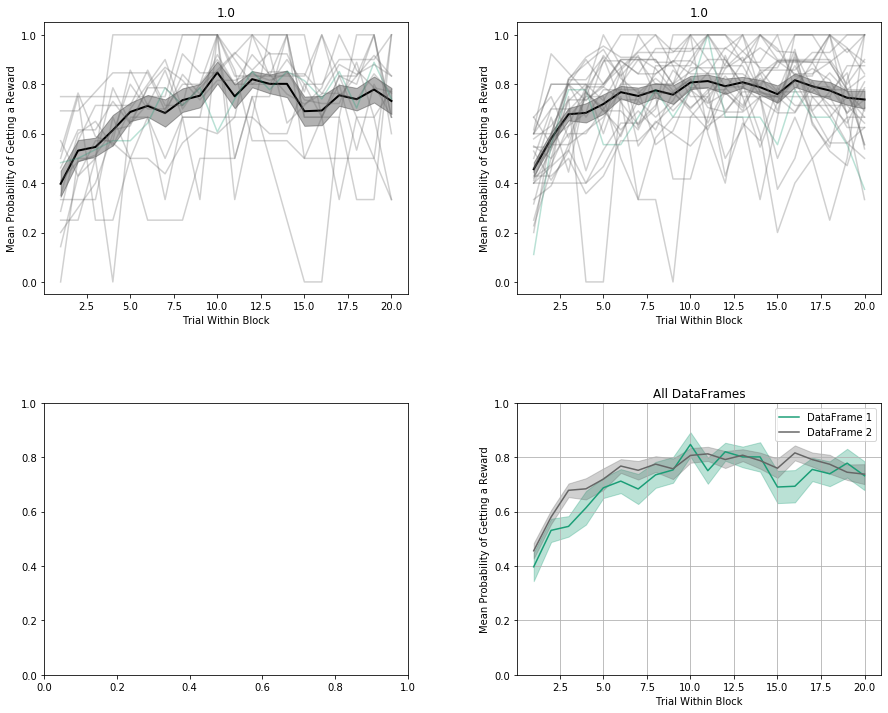

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Define your DataFrames
dataframes = [y_df_filtered_1, df_filtered_1]

# Create a color map for plotting individual means
colors = cm.get_cmap('Dark2', len(dataframes))  # 'Reds' color map

# Create a new figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Lists to store mean and standard error probabilities for each DataFrame
mean_probs_dict = {}
std_err_dict = {}

# Plot each DataFrame in its own subplot with mean and standard error
for idx, df_filtered in enumerate(dataframes):
    # Get unique dates from the 'Date' column
    dates = df_filtered['Date'].unique()

    # Determine valid dates where max TrialWithinBlock is 20
    valid_dates = []
    for date in dates:
        tmp = df_filtered[df_filtered['Date'] == date]
        if tmp['TrialWithinBlock'].max() <= 20 and tmp['Trial'].max() >= 60:
            valid_dates.append(date)

    # Sort valid dates
    valid_dates.sort()

    # List to store mean probabilities for the current DataFrame
    mean_probs_list = []

    # Calculate mean probabilities for each valid date
    for date in valid_dates:
        tmp = df_filtered[df_filtered['Date'] == date]
        mean_probs = tmp.groupby('TrialWithinBlock')['Outcome'].mean()
        mean_probs_list.append(mean_probs)

    # Calculate the overall average probability and standard error for the current DataFrame
    if mean_probs_list:
        all_mean_probs = pd.concat(mean_probs_list, axis=1)
        overall_avg_probs = all_mean_probs.mean(axis=1)
        overall_std_err = all_mean_probs.sem(axis=1)
        
        # Store the mean and standard error for later use
        mean_probs_dict[idx] = overall_avg_probs
        std_err_dict[idx] = overall_std_err

        # Plot the mean probabilities and error bars
        axs[idx//2, idx%2].plot(overall_avg_probs, color='black', linewidth=2, label='Overall Average')
        axs[idx//2, idx%2].fill_between(overall_avg_probs.index, 
                                         overall_avg_probs - overall_std_err, 
                                         overall_avg_probs + overall_std_err, 
                                         color='black', alpha=0.3)

        # Plot individual means
        for i, date in enumerate(valid_dates):
            tmp = df_filtered[df_filtered['Date'] == date]
            mean_probs = tmp.groupby('TrialWithinBlock')['Outcome'].mean()
            axs[idx//2, idx%2].plot(mean_probs, color=colors(i), alpha=0.3, label=f'Date {date}')
        
    axs[idx//2, idx%2].set_xlabel('Trial Within Block')
    axs[idx//2, idx%2].set_ylabel('Mean Probability of Getting a Reward')
    axs[idx//2, idx%2].set_title(max(tmp['ProbReward'].unique()))
    # axs[idx//2, idx%2].legend(False)
    # axs[idx//2, idx%2].grid(False)

# Plot all three DataFrames in the fourth subplot
plt.subplot(2, 2, 4)  # Fourth subplot
colors = cm.get_cmap('Dark2', len(dataframes))  # 'tab10' color map

# Plot the stored means and standard error for each DataFrame
for idx in range(len(dataframes)):
    plt.plot(mean_probs_dict[idx], color=colors(idx), label=f'DataFrame {idx+1}')
    plt.fill_between(mean_probs_dict[idx].index, 
                     mean_probs_dict[idx] - std_err_dict[idx], 
                     mean_probs_dict[idx] + std_err_dict[idx], 
                     color=colors(idx), alpha=0.3)

plt.xlabel('Trial Within Block')
plt.ylabel('Mean Probability of Getting a Reward')
plt.title('All DataFrames')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


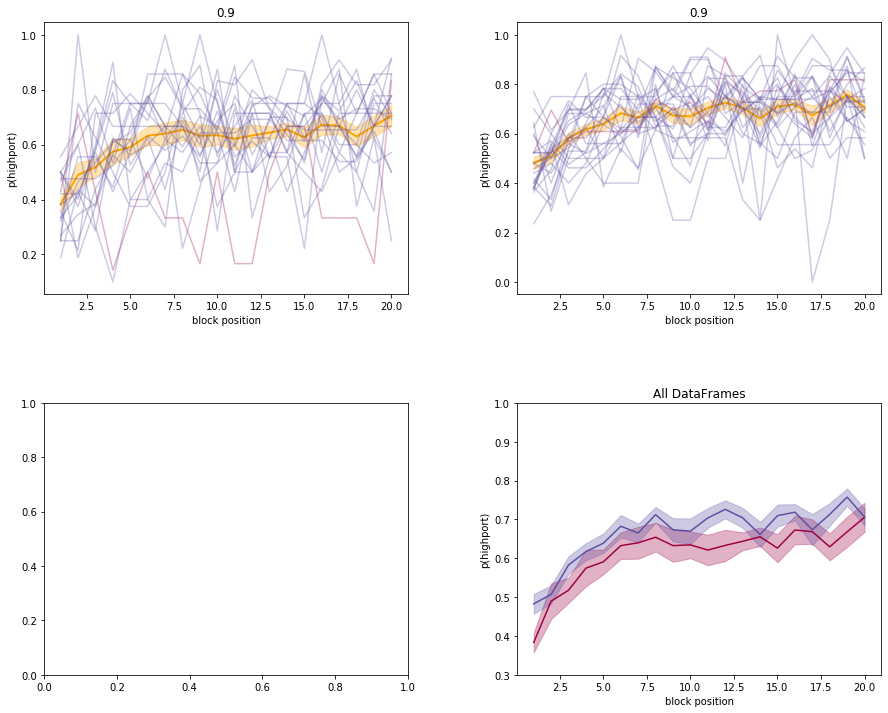

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Define your DataFrames
# dataframes = [y_df_filtered_1, y_df_filtered_2, y_df_filtered_3]
dataframes = [y_df_filtered_2, df_filtered_2]
# Create a blue color map for plotting individual means
colors = cm.get_cmap('Spectral', len(dataframes))  # 'Blues' color map

# Create a new figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Lists to store mean and standard error probabilities for each DataFrame
mean_probs_dict = {}
std_err_dict = {}

# Plot each DataFrame in its own subplot with mean and standard error
for idx, df_filtered in enumerate(dataframes):
    # Get unique dates from the 'Date' column
    dates = df_filtered['Date'].unique()

    # Determine valid dates where max TrialWithinBlock is 20
    valid_dates = []
    for date in dates:
        tmp = df_filtered[df_filtered['Date'] == date]
        if tmp['TrialWithinBlock'].max() <= 20 and tmp['Trial'].max() >= 60:
            valid_dates.append(date)

    # Sort valid dates
    valid_dates.sort()

    # List to store mean probabilities for the current DataFrame
    mean_probs_list = []

    # Calculate mean probabilities for each valid date
    for date in valid_dates:
        tmp = df_filtered[df_filtered['Date'] == date]
        mean_probs = tmp.groupby('TrialWithinBlock')['Outcome'].mean()
        mean_probs_list.append(mean_probs)

    # Calculate the overall average probability and standard error for the current DataFrame
    if mean_probs_list:
        all_mean_probs = pd.concat(mean_probs_list, axis=1)
        overall_avg_probs = all_mean_probs.mean(axis=1)
        overall_std_err = all_mean_probs.sem(axis=1)
        
        # Store the mean and standard error for later use
        mean_probs_dict[idx] = overall_avg_probs
        std_err_dict[idx] = overall_std_err

        # Plot the mean probabilities and error bars
        axs[idx//2, idx%2].plot(overall_avg_probs, color='orange', linewidth=2, label='Overall Average')
        axs[idx//2, idx%2].fill_between(overall_avg_probs.index, 
                                         overall_avg_probs - overall_std_err, 
                                         overall_avg_probs + overall_std_err, 
                                         color='orange', alpha=0.3)

        # Plot individual means
        for i, date in enumerate(valid_dates):
            tmp = df_filtered[df_filtered['Date'] == date]
            mean_probs = tmp.groupby('TrialWithinBlock')['Outcome'].mean()
            axs[idx//2, idx%2].plot(mean_probs, color=colors(i), alpha=0.3, label=f'Date {date}')
        
    axs[idx//2, idx%2].set_xlabel('block position')
    axs[idx//2, idx%2].set_ylabel('p(highport)')
    axs[idx//2, idx%2].set_title(max(tmp['ProbReward'].unique()))
    # axs[idx//2, idx%2].legend(False)
    # axs[idx//2, idx%2].grid(False)

    # Save each subplot as SVG
    plt.savefig(f'plot_{idx}.svg')

# Plot all three DataFrames in the fourth subplot
plt.subplot(2, 2, 4)  # Fourth subplot
colors = cm.get_cmap('Spectral', len(dataframes))  # 'Blues' color map

# Plot the stored means and standard error for each DataFrame
for idx in range(len(dataframes)):
    plt.plot(mean_probs_dict[idx], color=colors(idx), label=f'DataFrame {idx+1}')
    plt.fill_between(mean_probs_dict[idx].index, 
                     mean_probs_dict[idx] - std_err_dict[idx], 
                     mean_probs_dict[idx] + std_err_dict[idx], 
                     color=colors(idx), alpha=0.3)

plt.xlabel('block position')
plt.ylim(0.3,1.0)
plt.ylabel('p(highport)')
plt.title('All DataFrames')
# plt.legend()
plt.grid(False)

# Save the combined plot as SVG
plt.savefig('old_whereblocks.svg')

# Show the plot
plt.show()

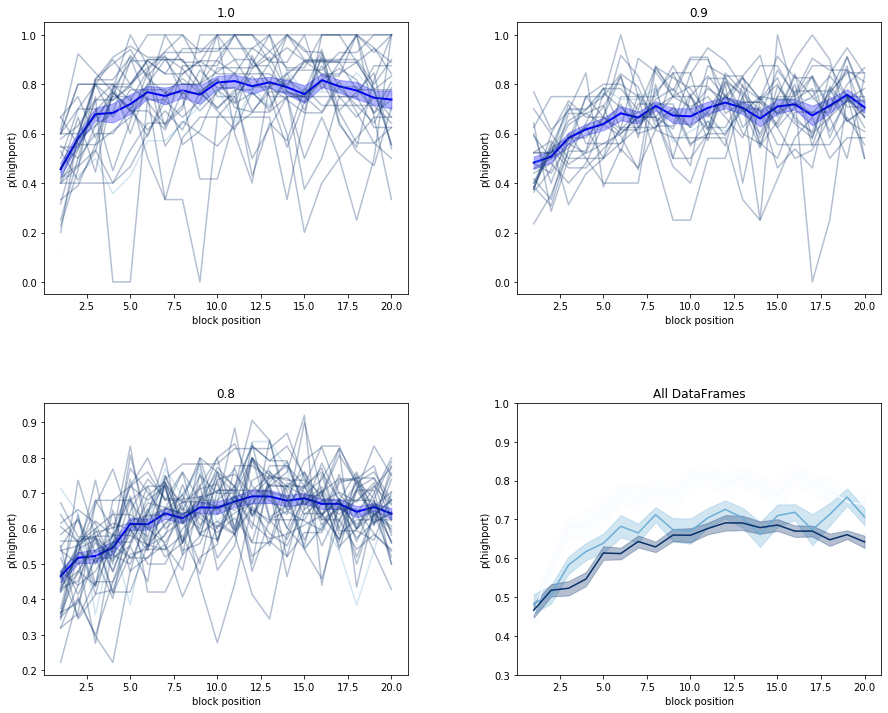

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Define your DataFrames
# dataframes = [y_df_filtered_1, y_df_filtered_2, y_df_filtered_3]
dataframes = [df_filtered_1, df_filtered_2, df_filtered_3]
# Create a blue color map for plotting individual means
colors = cm.get_cmap('Blues', len(dataframes))  # 'Blues' color map

# Create a new figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Lists to store mean and standard error probabilities for each DataFrame
mean_probs_dict = {}
std_err_dict = {}

# Plot each DataFrame in its own subplot with mean and standard error
for idx, df_filtered in enumerate(dataframes):
    # Get unique dates from the 'Date' column
    dates = df_filtered['Date'].unique()

    # Determine valid dates where max TrialWithinBlock is 20
    valid_dates = []
    for date in dates:
        tmp = df_filtered[df_filtered['Date'] == date]
        if tmp['TrialWithinBlock'].max() <= 20 and tmp['Trial'].max() >= 60:
            valid_dates.append(date)

    # Sort valid dates
    valid_dates.sort()

    # List to store mean probabilities for the current DataFrame
    mean_probs_list = []

    # Calculate mean probabilities for each valid date
    for date in valid_dates:
        tmp = df_filtered[df_filtered['Date'] == date]
        mean_probs = tmp.groupby('TrialWithinBlock')['Outcome'].mean()
        mean_probs_list.append(mean_probs)

    # Calculate the overall average probability and standard error for the current DataFrame
    if mean_probs_list:
        all_mean_probs = pd.concat(mean_probs_list, axis=1)
        overall_avg_probs = all_mean_probs.mean(axis=1)
        overall_std_err = all_mean_probs.sem(axis=1)
        
        # Store the mean and standard error for later use
        mean_probs_dict[idx] = overall_avg_probs
        std_err_dict[idx] = overall_std_err

        # Plot the mean probabilities and error bars
        axs[idx//2, idx%2].plot(overall_avg_probs, color='blue', linewidth=2, label='Overall Average')
        axs[idx//2, idx%2].fill_between(overall_avg_probs.index, 
                                         overall_avg_probs - overall_std_err, 
                                         overall_avg_probs + overall_std_err, 
                                         color='blue', alpha=0.3)

        # Plot individual means
        for i, date in enumerate(valid_dates):
            tmp = df_filtered[df_filtered['Date'] == date]
            mean_probs = tmp.groupby('TrialWithinBlock')['Outcome'].mean()
            axs[idx//2, idx%2].plot(mean_probs, color=colors(i), alpha=0.3, label=f'Date {date}')
        
    axs[idx//2, idx%2].set_xlabel('block position')
    axs[idx//2, idx%2].set_ylabel('p(highport)')
    axs[idx//2, idx%2].set_title(max(tmp['ProbReward'].unique()))
    # axs[idx//2, idx%2].legend(False)
    # axs[idx//2, idx%2].grid(False)

    # Save each subplot as SVG
    plt.savefig(f'plot_{idx}.svg')

# Plot all three DataFrames in the fourth subplot
plt.subplot(2, 2, 4)  # Fourth subplot
colors = cm.get_cmap('Blues', len(dataframes))  # 'Blues' color map

# Plot the stored means and standard error for each DataFrame
for idx in range(len(dataframes)):
    plt.plot(mean_probs_dict[idx], color=colors(idx), label=f'DataFrame {idx+1}')
    plt.fill_between(mean_probs_dict[idx].index, 
                     mean_probs_dict[idx] - std_err_dict[idx], 
                     mean_probs_dict[idx] + std_err_dict[idx], 
                     color=colors(idx), alpha=0.3)

plt.xlabel('block position')
plt.ylim(0.3,1.0)
plt.ylabel('p(highport)')
plt.title('All DataFrames')
# plt.legend()
plt.grid(False)

# Save the combined plot as SVG
plt.savefig('old_whereblocks.svg')

# Show the plot
plt.show()


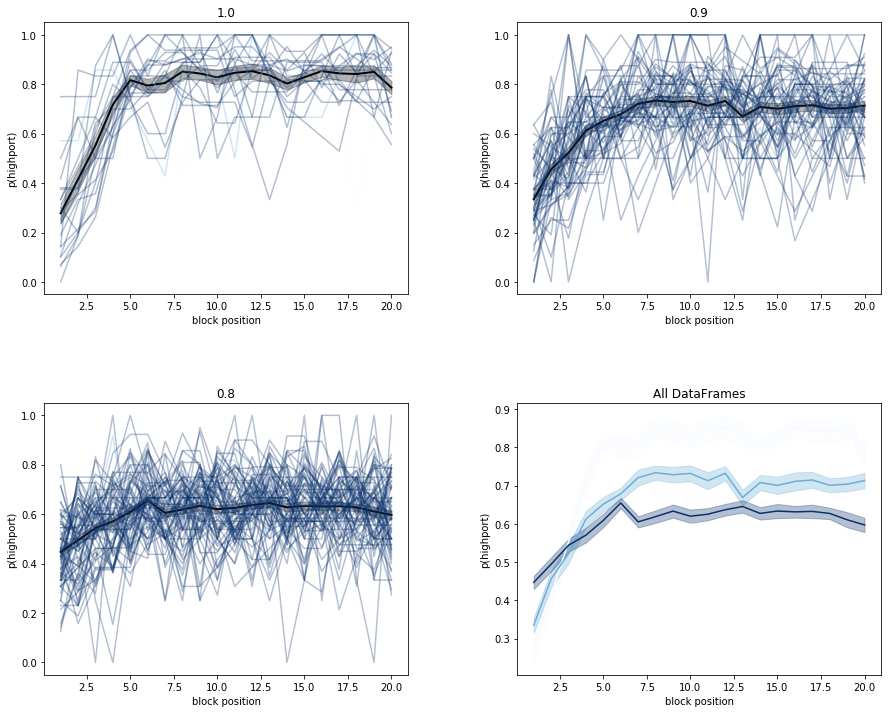

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Define your DataFrames
dataframes = [df_reversal_1, df_reversal_2, df_reversal_3]


# Create a blue color map for plotting individual means
colors = cm.get_cmap('Blues', len(dataframes))  # 'Blues' color map

# Create a new figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Lists to store mean and standard error probabilities for each DataFrame
mean_probs_dict = {}
std_err_dict = {}

# Plot each DataFrame in its own subplot with mean and standard error
for idx, df_filtered in enumerate(dataframes):
    # Get unique dates from the 'Date' column
    dates = df_filtered['Date'].unique()

    # Determine valid dates where max TrialWithinBlock is 20
    valid_dates = []
    for date in dates:
        tmp = df_filtered[df_filtered['Date'] == date]
        if tmp['TrialWithinBlock'].max() <= 20 and tmp['Trial'].max() >= 60:
            valid_dates.append(date)

    # Sort valid dates
    valid_dates.sort()

    # List to store mean probabilities for the current DataFrame
    mean_probs_list = []

    # Calculate mean probabilities for each valid date
    for date in valid_dates:
        tmp = df_filtered[df_filtered['Date'] == date]
        mean_probs = tmp.groupby('TrialWithinBlock')['Outcome'].mean()
        mean_probs_list.append(mean_probs)

    # Calculate the overall average probability and standard error for the current DataFrame
    if mean_probs_list:
        all_mean_probs = pd.concat(mean_probs_list, axis=1)
        overall_avg_probs = all_mean_probs.mean(axis=1)
        overall_std_err = all_mean_probs.sem(axis=1)
        
        # Store the mean and standard error for later use
        mean_probs_dict[idx] = overall_avg_probs
        std_err_dict[idx] = overall_std_err

        # Plot the mean probabilities and error bars
        axs[idx//2, idx%2].plot(overall_avg_probs, color='black', linewidth=2, label='Overall Average')
        axs[idx//2, idx%2].fill_between(overall_avg_probs.index, 
                                         overall_avg_probs - overall_std_err, 
                                         overall_avg_probs + overall_std_err, 
                                         color='black', alpha=0.3)

        # Plot individual means
        for i, date in enumerate(valid_dates):
            tmp = df_filtered[df_filtered['Date'] == date]
            mean_probs = tmp.groupby('TrialWithinBlock')['Outcome'].mean()
            axs[idx//2, idx%2].plot(mean_probs, color=colors(i), alpha=0.3, label=f'Date {date}')
        
    axs[idx//2, idx%2].set_xlabel('block position')
    axs[idx//2, idx%2].set_ylabel('p(highport)')
    axs[idx//2, idx%2].set_title(max(tmp['ProbReward'].unique()))
    # axs[idx//2, idx%2].legend(False)
    # axs[idx//2, idx%2].grid(False)

    # Save each subplot as SVG
    plt.savefig(f'plot_{idx}.svg')

# Plot all three DataFrames in the fourth subplot
plt.subplot(2, 2, 4)  # Fourth subplot
colors = cm.get_cmap('Blues', len(dataframes))  # 'Blues' color map

# Plot the stored means and standard error for each DataFrame
for idx in range(len(dataframes)):
    plt.plot(mean_probs_dict[idx], color=colors(idx), label=f'DataFrame {idx+1}')
    plt.fill_between(mean_probs_dict[idx].index, 
                     mean_probs_dict[idx] - std_err_dict[idx], 
                     mean_probs_dict[idx] + std_err_dict[idx], 
                     color=colors(idx), alpha=0.3)

plt.xlabel('block position')
plt.ylabel('p(highport)')
plt.title('All DataFrames')
# plt.legend()
plt.grid(False)

# Save the combined plot as SVG
plt.savefig('Mouse_all_dataframes.svg')

# Show the plot
plt.show()



In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Define your DataFrames
dataframes = [df_reversal_1, df_reversal_2, df_reversal_3]

# Create a blue color map for plotting individual means
colors = cm.get_cmap('Blues', len(dataframes))  # 'Blues' color map

# Create a new figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Lists to store mean and standard error probabilities for each DataFrame
mean_probs_dict = {}
std_err_dict = {}

# Plot each DataFrame in its own subplot with mean and standard error
for idx, df_filtered in enumerate(dataframes):
    # Get unique dates from the 'Date' column
    dates = df_filtered['Date'].unique()

    # Determine valid dates where max TrialWithinBlock is 20
    valid_dates = []
    for date in dates:
        tmp = df_filtered[df_filtered['Date'] == date]
        if tmp['TrialWithinBlock'].max() <= 20 and tmp['Trial'].max() >= 60:
            valid_dates.append(date)

    # Sort valid dates
    valid_dates.sort()

    # List to store mean probabilities for the current DataFrame
    mean_probs_list = []

    # Calculate mean probabilities for each valid date
    for date in valid_dates:
        tmp = df_filtered[df_filtered['Date'] == date]
        mean_probs = tmp.groupby('TrialWithinBlock')['Outcome'].mean()
        mean_probs_list.append(mean_probs)

    # Calculate the overall average probability and standard error for the current DataFrame
    if mean_probs_list:
        all_mean_probs = pd.concat(mean_probs_list, axis=1)
        overall_avg_probs = all_mean_probs.mean(axis=1)
        overall_std_err = all_mean_probs.sem(axis=1)
        
        # Store the mean and standard error for later use
        mean_probs_dict[idx] = overall_avg_probs
        std_err_dict[idx] = overall_std_err

        # Plot the mean probabilities and error bars
        axs[idx//2, idx%2].plot(overall_avg_probs, color='black', linewidth=2, label='Overall Average')
        axs[idx//2, idx%2].fill_between(overall_avg_probs.index, 
                                         overall_avg_probs - overall_std_err, 
                                         overall_avg_probs + overall_std_err, 
                                         color='black', alpha=0.3)

        # Plot individual means
        for i, date in enumerate(valid_dates):
            tmp = df_filtered[df_filtered['Date'] == date]
            mean_probs = tmp.groupby('TrialWithinBlock')['Outcome'].mean()
            axs[idx//2, idx%2].plot(mean_probs, color=colors(i), alpha=0.7, label=f'Date {date}')
        
    axs[idx//2, idx%2].set_xlabel('Trial Within Block')
    axs[idx//2, idx%2].set_ylabel('Mean Probability of Getting a Reward')
    axs[idx//2, idx%2].set_title(max(tmp['ProbReward'].unique()))
    axs[idx//2, idx%2].legend()
    axs[idx//2, idx%2].grid(True)

    # Save each subplot as SVG
    plt.savefig(f'plot_{idx}.svg', format='svg')

# Plot all three DataFrames in the fourth subplot
plt.subplot(2, 2, 4)  # Fourth subplot

# Plot the stored means and standard error for each DataFrame
for idx in range(len(dataframes)):
    plt.plot(mean_probs_dict[idx], color=colors(idx), label=f'DataFrame {idx+1}')
    plt.fill_between(mean_probs_dict[idx].index, 
                     mean_probs_dict[idx] - std_err_dict[idx], 
                     mean_probs_dict[idx] + std_err_dict[idx], 
                     color=colors(idx), alpha=0.3)

plt.xlabel('Trial Within Block')
plt.ylabel('Mean Probability of Getting a Reward')
plt.title('All DataFrames')
plt.legend()
plt.grid(True)

# Save the combined plot as SVG
plt.savefig('all_dataframes.svg', format='svg')

# Show the plot
plt.show()


452      1
453      1
454      1
455      1
456      1
        ..
23387    8
23388    8
23389    8
23390    5
23391    5
Name: Block, Length: 2225, dtype: int64

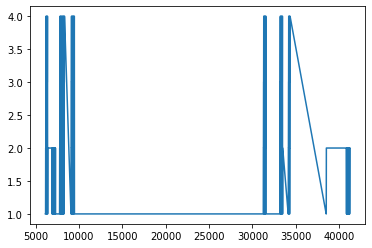

In [126]:
plt.plot(df_reversal_1['Block'])

In [142]:
#iterate through unique 'Date' to find a session that only has a Block.unique() == 1    
for date in df_reversal_3['Date'].unique():
    tmp = df_reversal_3[df_reversal_3['Date'] == date]
    if len(tmp['Block'].unique()) == 1:
        print(date)
        break
    else:
        print('more blocks')
        continue






more blocks
more blocks
more blocks
more blocks
more blocks
01/19/2023


In [149]:
#subset 01/19/2023
df_reversal_3_01192023 = df_reversal_2[df_reversal_2['Date'] == '01/27/2023']


In [150]:
df_reversal_3_01192023

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,TaskObject2_Size1,TaskObject2_Size2,TaskObject3_Type,TaskObject3_Source,TaskObject3_LocX,TaskObject3_LocY,TaskObject3_Size1,TaskObject3_Size2,Date,Outcome
14561,1,1,1,2,2,0,NaN,0.000000e+00,2023,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/27/2023,1
14562,2,1,2,2,2,6,NaN,9.376316e+04,2023,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/27/2023,0
14563,3,1,3,2,2,0,NaN,9.924584e+04,2023,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/27/2023,1
14564,4,1,4,2,2,0,NaN,1.041788e+05,2023,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/27/2023,1
14565,5,1,5,2,2,6,NaN,1.074477e+05,2023,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/27/2023,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14861,301,16,1,1,1,6,NaN,3.253413e+06,2023,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/27/2023,1
14862,302,16,2,1,1,0,NaN,3.255680e+06,2023,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/27/2023,0
14863,303,16,3,1,1,6,NaN,3.265512e+06,2023,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/27/2023,0
14864,304,16,4,1,1,0,NaN,3.279610e+06,2023,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01/27/2023,1
